### Unsupervised Learning

In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.metrics import silhouette_score

#### Dataset Link

https://www.kaggle.com/datasets/ybifoundation/credit-card-transaction

In [3]:
#Importing the Dataset
df = pd.read_csv(r"C:\Users\gamag\Downloads\CreditCardTransaction.csv")
df.head()

,Year,Month,Department,Division,Merchant,TranxDescription,TranxDate,TrnxAmount
0,2019,1,LEGISLATIVE BRANCH,General Assembly House,USPS PO 0917600901,Postal Services-Government Only,06/29/2018,9.85
1,2019,1,LEGISLATIVE BRANCH,General Assembly House,GAN*NEWSPAPER SUB1052,Direct Marketing-Continuity-Subscription Merch...,07-03-2018,15.00
2,2019,1,LEGISLATIVE BRANCH,General Assembly House,DS SERVICES STANDARD COFF,Nondurable Goods Not Elsewhere Classified,07-01-2018,170.31
3,2019,1,LEGISLATIVE BRANCH,General Assembly House,BETHANY BLUES - LEWES,Eating Places Restaurants,06/30/2018,3427.80
4,2019,1,LEGISLATIVE BRANCH,General Assembly House,XEROX CORPORATION/RBO,Office Photographic Photocopy Microfilm Equipmt,06/27/2018,113.06


### Exploratory Data Analysis

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 788521 entries, 0 to 788520
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Year              788521 non-null  int64  
 1   Month             788521 non-null  int64  
 2   Department        788521 non-null  object 
 3   Division          788521 non-null  object 
 4   Merchant          788521 non-null  object 
 5   TranxDescription  788521 non-null  object 
 6   TranxDate         788521 non-null  object 
 7   TrnxAmount        788521 non-null  float64
dtypes: float64(1), int64(2), object(5)
memory usage: 48.1+ MB


In [8]:
# Distribution of the numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,788521.0,2020.750357,1.381895,2019.0,2020.0,2021.00,2022.00,2023.00
Month,788521.0,6.076380,3.383734,1.0,3.0,6.00,9.00,12.00
TrnxAmount,788521.0,428.631052,2482.957235,-86114.2,22.0,70.95,259.88,432159.84


In [10]:
# Obtaining the list of categorical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols

['Department', 'Division', 'Merchant', 'TranxDescription', 'TranxDate']

C:\Users\gamag\AppData\Local\Temp\ipykernel_7544\746715984.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df[df[col].isin(top_categories)], order=top_categories, palette='viridis', legend=False)


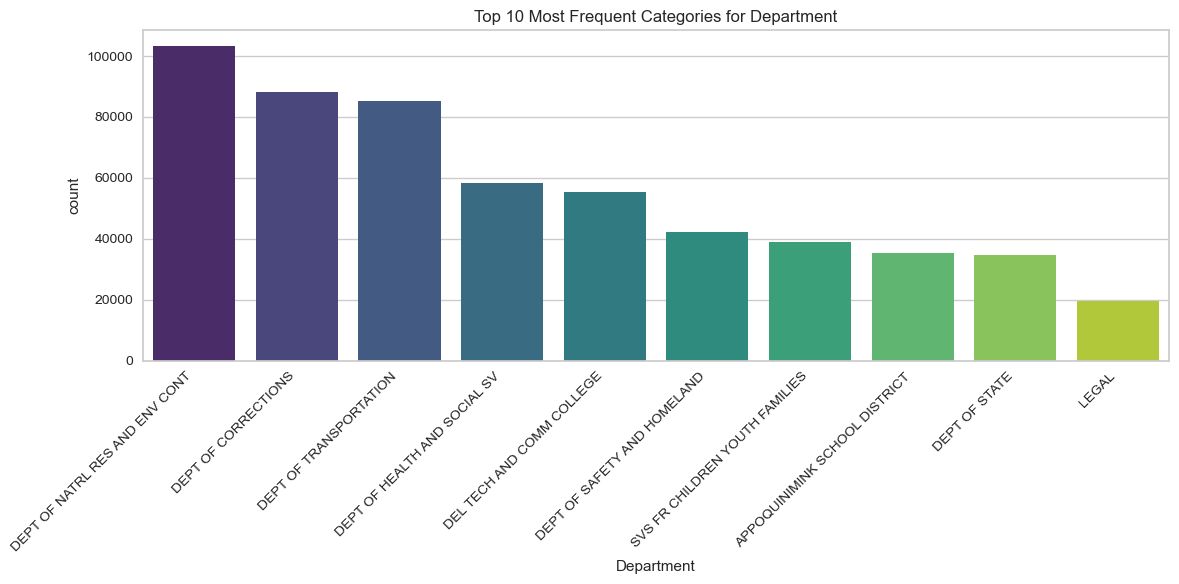

C:\Users\gamag\AppData\Local\Temp\ipykernel_7544\746715984.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df[df[col].isin(top_categories)], order=top_categories, palette='viridis', legend=False)


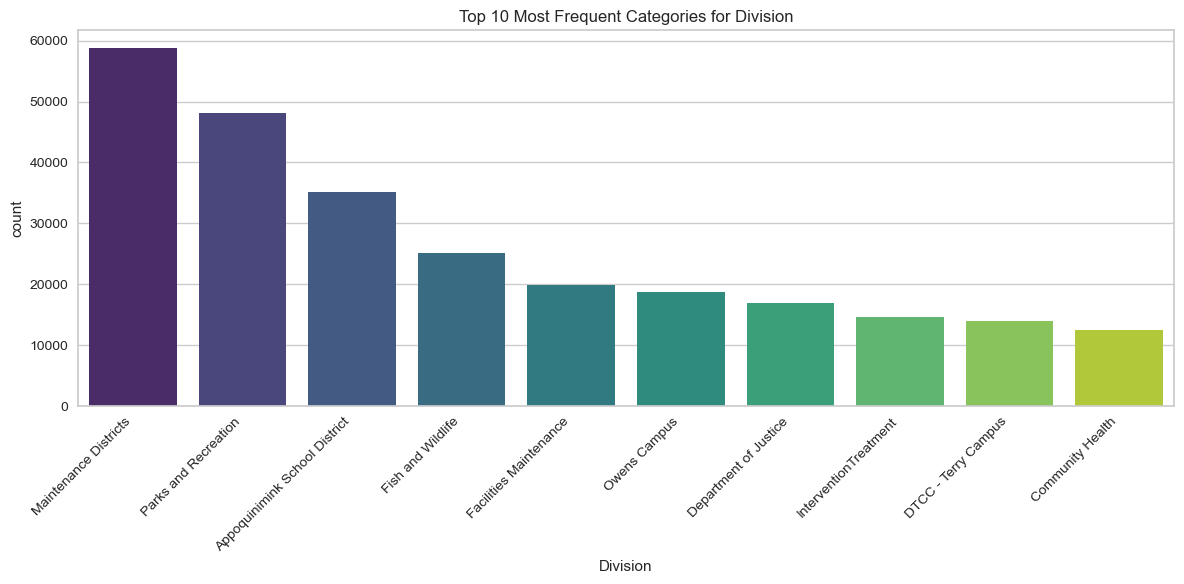

C:\Users\gamag\AppData\Local\Temp\ipykernel_7544\746715984.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df[df[col].isin(top_categories)], order=top_categories, palette='viridis', legend=False)


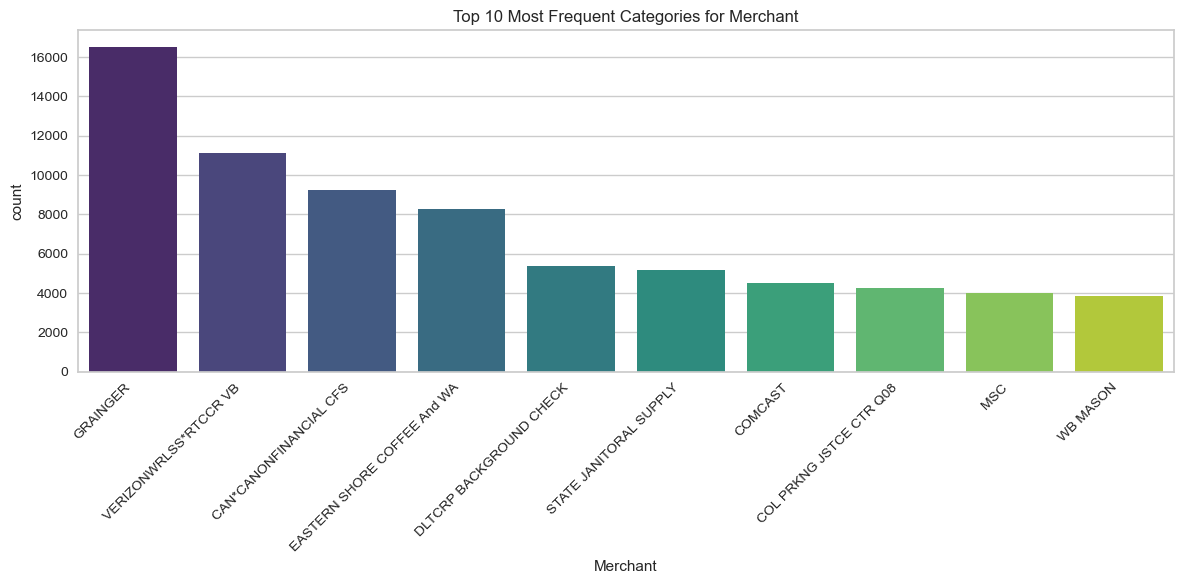

C:\Users\gamag\AppData\Local\Temp\ipykernel_7544\746715984.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df[df[col].isin(top_categories)], order=top_categories, palette='viridis', legend=False)


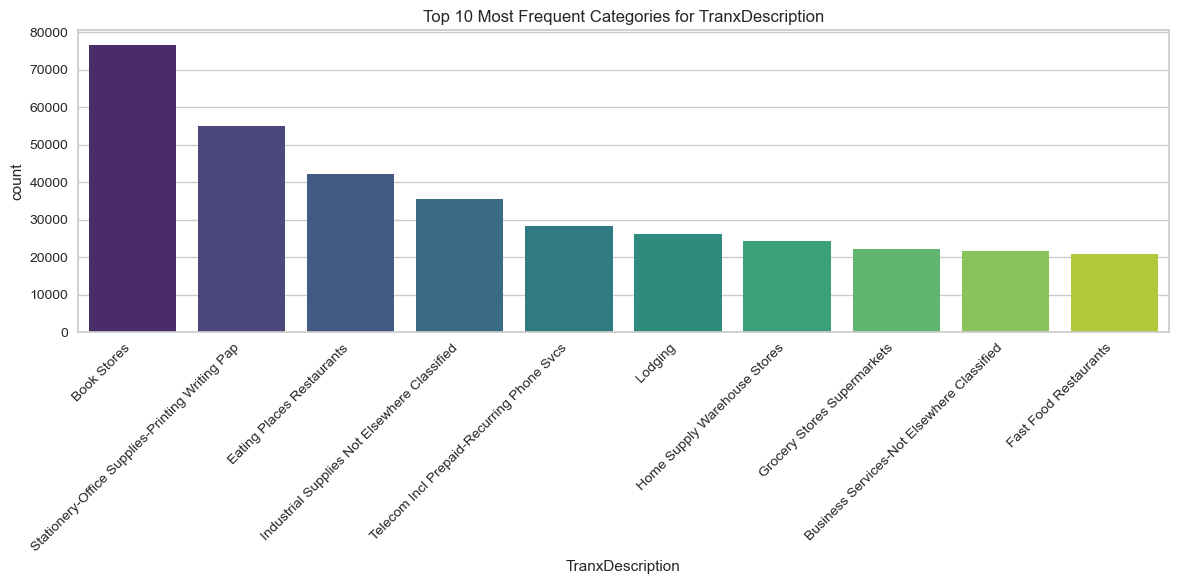

In [12]:
# Re-obtaining the list of categorical columns, excluding 'TranxDate' for now
cat_cols_for_plot = [col for col in df.select_dtypes(include=['object', 'category']).columns.tolist() if col != 'TranxDate']

for col in cat_cols_for_plot:
    plt.figure(figsize=(12, 6))
    # Check the number of unique values for each column (showing top 10)
    if df[col].nunique() > 20:
        top_categories = df[col].value_counts().nlargest(10).index
        sns.countplot(x=col, data=df[df[col].isin(top_categories)], order=top_categories, palette='viridis', legend=False)
        plt.title(f'Top 10 Most Frequent Categories for {col}')
        plt.xticks(rotation=45, ha='right')
    else:
        sns.countplot(x=col, data=df, palette='viridis', legend=False)
        plt.title(f'Bar plot for {col}')
        plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

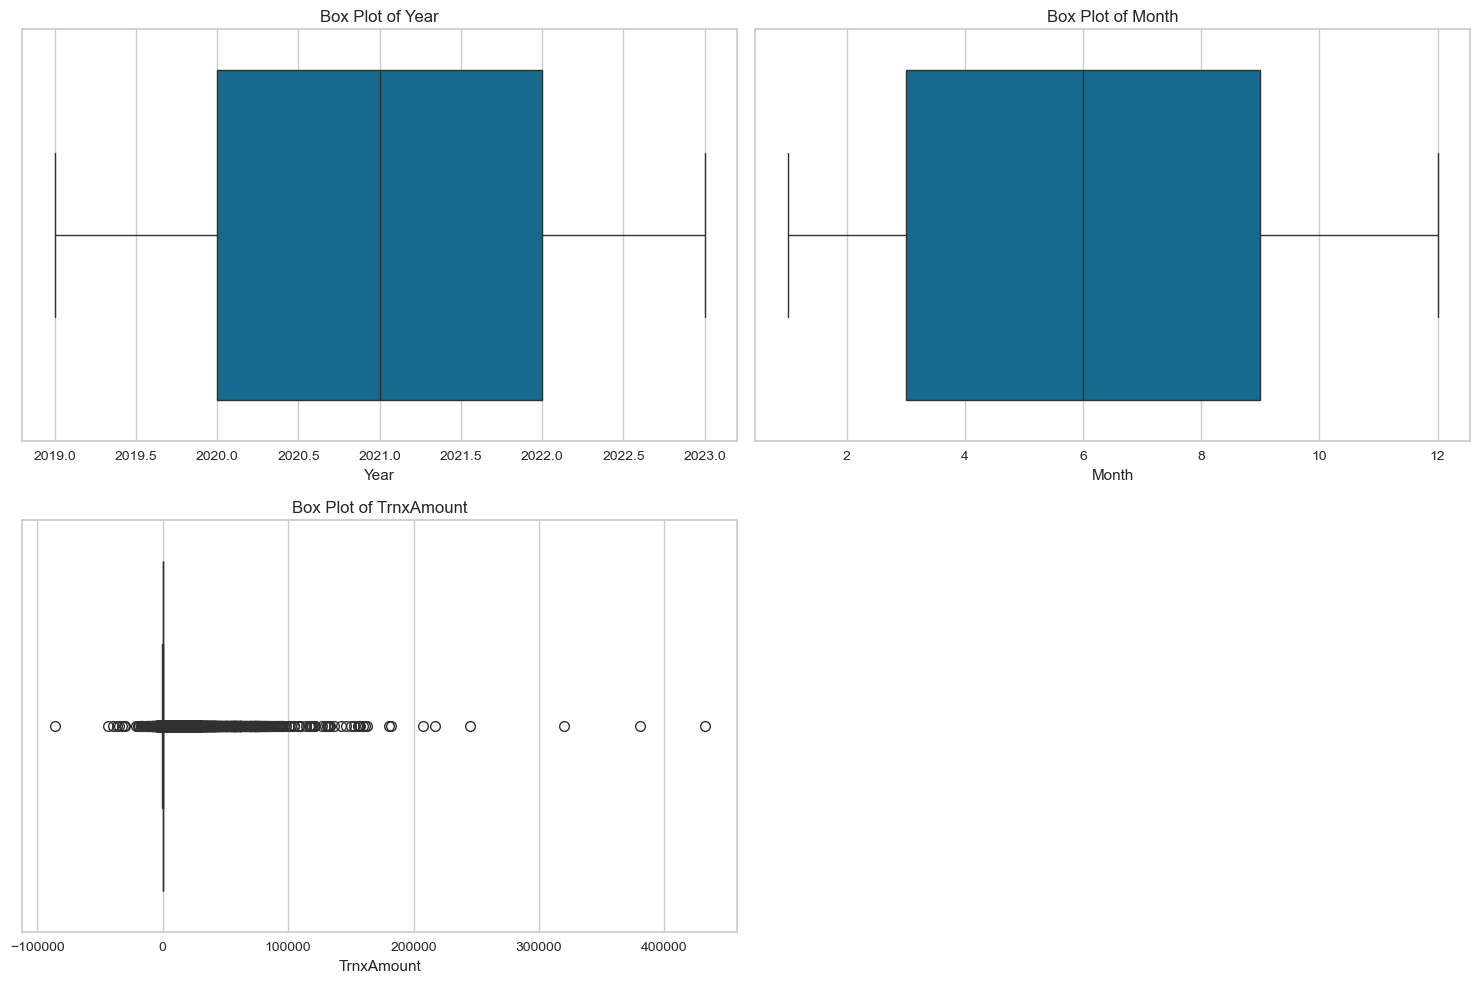

In [13]:
# Obtaining the list of numerical columns
num_cols = df.select_dtypes(include=['number']).columns.tolist()
num_cols

# Creating subplots
n_cols = 2
n_rows = -(-len(num_cols) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, column in enumerate(num_cols):
    sns.boxplot(x=df[column], ax=axes[i])
    axes[i].set_title(f'Box Plot of {column}')
    axes[i].set_xlabel(column)

for i in range(len(num_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

<Figure size 1000x1000 with 0 Axes>

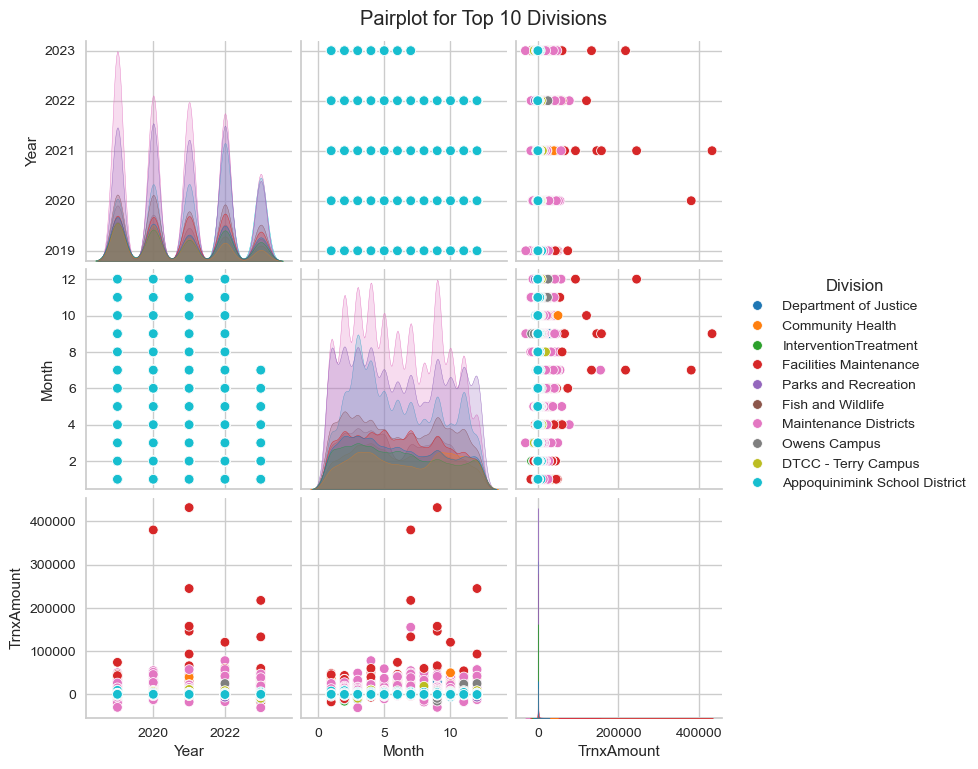

In [14]:
# Get the top 10 unique 'Division' values
top_10_divisions = df['Division'].value_counts().nlargest(10).index.tolist()

df_top_10_divisions = df[df['Division'].isin(top_10_divisions)]

plt.figure(figsize=(10, 10))
sns.pairplot(df_top_10_divisions, hue='Division', palette='tab10')
plt.suptitle('Pairplot for Top 10 Divisions', y=1.02)
plt.show()

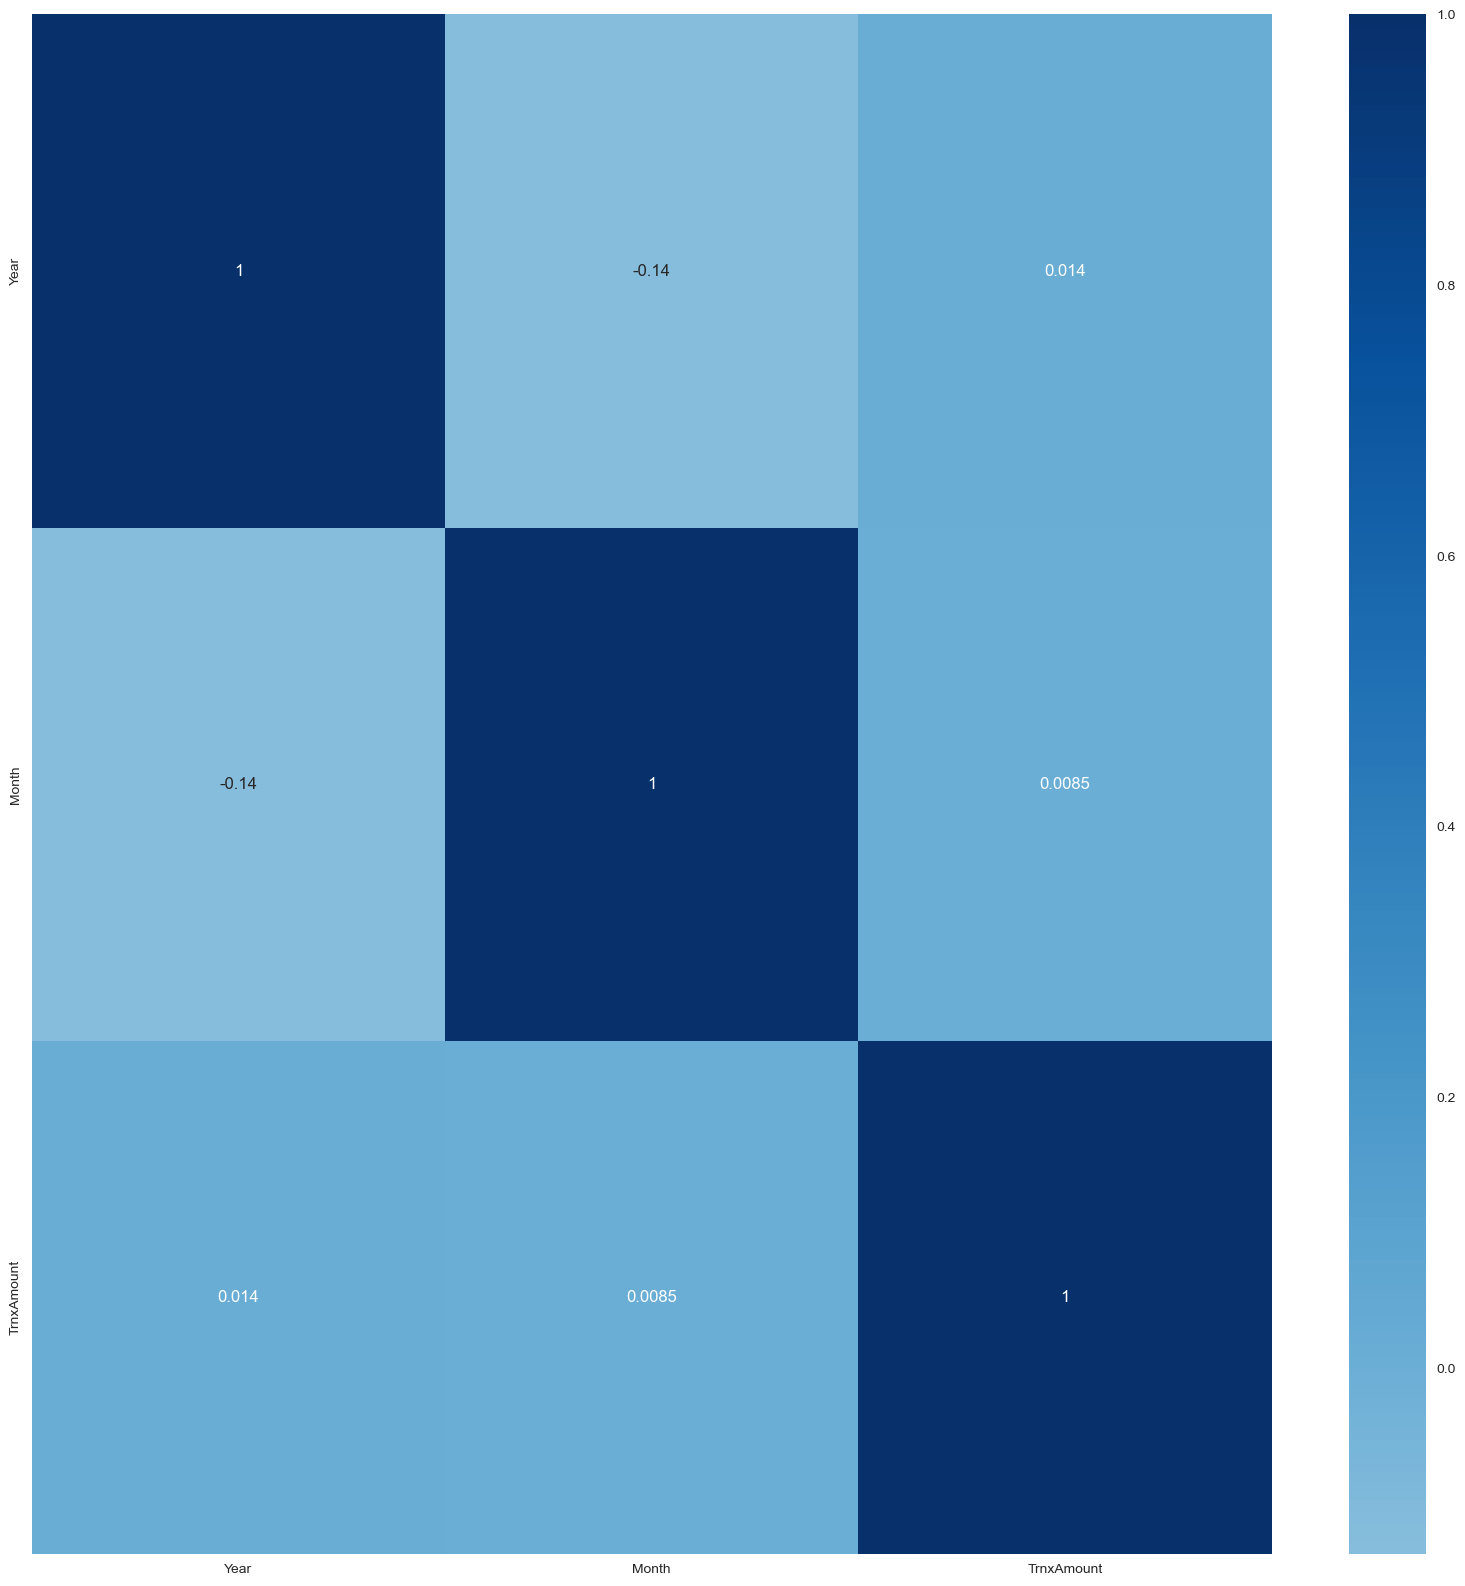

In [15]:
# Creating a correlation heatmap to visualize the correlation among the features

numeric_df = df.select_dtypes(include=['float64', 'int64'])
corrmat = numeric_df.corr()
plt.figure(figsize=(20,20))
sns.heatmap(corrmat, annot=True, cmap='Blues', center=0)
plt.show()

**Data Preprocessing**

In [17]:
#Checking for null values
total = df.isnull().sum().sort_values(ascending=False)
percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(6)

,Total,Percent
Year,0,0.0
Month,0,0.0
Department,0,0.0
Division,0,0.0
Merchant,0,0.0
TranxDescription,0,0.0


In [18]:
# Separate columns for imputation based on their data type
numeric_cols_to_impute = ['TrnxAmount']
categorical_cols_to_impute = ['TranxDate', 'TranxDescription']


for column in numeric_cols_to_impute:
    mean_value = df[column].mean()
    df[column] = df[column].fillna(mean_value)


for column in categorical_cols_to_impute:

    mode_value = df[column].mode()[0]
    df[column] = df[column].fillna(mode_value)



In [19]:
df['TranxDescription'].value_counts()

TranxDescription
Book Stores                                        76704
Stationery-Office Supplies-Printing Writing Pap    55123
Eating Places Restaurants                          42129
Industrial Supplies Not Elsewhere Classified       35522
Telecom Incl Prepaid-Recurring Phone Svcs          28282
                                                   ...  
Health And Beauty Spas                                 1
Chiropodists Podiatrists                               1
Telegraph Services                                     1
Securities-Brokers-Dealers                             1
Tire Retreading And Repair Shops                       1
Name: count, Length: 255, dtype: int64

In [20]:
#Re-checking for null values
total = df.isnull().sum().sort_values(ascending=False)
percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
print(missing_data.head(5))

print("All null values have been successfully imputed")

            Total  Percent
Year            0      0.0
Month           0      0.0
Department      0      0.0
Division        0      0.0
Merchant        0      0.0
All null values have been successfully imputed


In [21]:
# Find and display duplicate rows
duplicates = df[df.duplicated()]
duplicates

,Year,Month,Department,Division,Merchant,TranxDescription,TranxDate,TrnxAmount
103,2019,1,JUDICIAL,Superior Court,AT And T DATA,Telecom Incl Prepaid-Recurring Phone Svcs,07-12-2018,30.00
148,2019,1,JUDICIAL,Superior Court,COLONIAL PARKING CORP.,Automobile Parking Lots And Garages,07-01-2018,130.00
177,2019,1,JUDICIAL,Family Court,CAN*CANONFINANCIAL CFS,Electronic Sales,07/24/2018,284.00
205,2019,1,JUDICIAL,Family Court,CAN*CANONFINANCIAL CFS,Electronic Sales,07/24/2018,284.00
222,2019,1,JUDICIAL,Justice of the Peace Court,7 SPRINGS LODGING,Lodging,07/26/2018,103.23
...,...,...,...,...,...,...,...,...
788422,2023,7,EARLY COLLEGE HIGH SCHOOL,Early College High School,SAMS CLUB #6330,Wholesale Clubs,01/26/2023,116.74
788435,2023,7,EARLY COLLEGE HIGH SCHOOL,Early College High School,NATL AFTERSCHOOL ASSOC,Schools Trade And Vocational,01-04-2023,595.00
788440,2023,7,EARLY COLLEGE HIGH SCHOOL,Early College High School,GAYLORD PALMS RSRT CC,Lodging,01-09-2023,267.93
788477,2023,7,ACADEMIA ANTONIA ALONSO,Academia Antonia Alonso,NJ EZPASS,Bridge And Road Fees Tolls,01-12-2023,37.00


In [22]:
#Removing Duplicates
df_no_duplicates = df.drop_duplicates()
print("\nDataFrame after removing duplicates:")
print(df_no_duplicates)


DataFrame after removing duplicates:
        Year  Month             Department                Division  \
0       2019      1     LEGISLATIVE BRANCH  General Assembly House   
1       2019      1     LEGISLATIVE BRANCH  General Assembly House   
2       2019      1     LEGISLATIVE BRANCH  General Assembly House   
3       2019      1     LEGISLATIVE BRANCH  General Assembly House   
4       2019      1     LEGISLATIVE BRANCH  General Assembly House   
...      ...    ...                    ...                     ...   
788516  2023      7  FREIRE CHARTER SCHOOL   Freire Charter School   
788517  2023      7  FREIRE CHARTER SCHOOL   Freire Charter School   
788518  2023      7  FREIRE CHARTER SCHOOL   Freire Charter School   
788519  2023      7  FREIRE CHARTER SCHOOL   Freire Charter School   
788520  2023      7  FREIRE CHARTER SCHOOL   Freire Charter School   

                         Merchant  \
0              USPS PO 0917600901   
1           GAN*NEWSPAPER SUB1052   
2       DS

### Exploratory Data Analysis (After cleaning the data)

In [24]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,788521.0,2020.750357,1.381895,2019.0,2020.0,2021.00,2022.00,2023.00
Month,788521.0,6.076380,3.383734,1.0,3.0,6.00,9.00,12.00
TrnxAmount,788521.0,428.631052,2482.957235,-86114.2,22.0,70.95,259.88,432159.84


#### Visualizations for Numerical Columns

For `Year` and `Month`, which are discrete variables, histograms provide a clearer view of their distributions than boxplots.

For `TrnxAmount`, which has a wide range and extreme outliers, a combination of a histogram/KDE plot and a boxplot with a focused y-axis range can offer better insights into its distribution.

### **Feature Engineering and Preparation for Unsupervised Learning**

In [30]:
# Selecting relevant features for clustering
# Dropping 'TranxDate' as it has been handled, and 'Merchant' and 'Department' have very high cardinality which might make clustering difficult initially.
# focusing on 'Division', 'TranxDescription', 'Year', 'Month', and 'TrnxAmount'.

df_clustering = df[['Division', 'TranxDescription', 'Year', 'Month', 'TrnxAmount']].copy()
df_clustering.head()

,Division,TranxDescription,Year,Month,TrnxAmount
0,General Assembly House,Postal Services-Government Only,2019,1,9.85
1,General Assembly House,Direct Marketing-Continuity-Subscription Merch...,2019,1,15.00
2,General Assembly House,Nondurable Goods Not Elsewhere Classified,2019,1,170.31
3,General Assembly House,Eating Places Restaurants,2019,1,3427.80
4,General Assembly House,Office Photographic Photocopy Microfilm Equipmt,2019,1,113.06


In [31]:
# One-Hot Encode categorical features
categorical_features_for_clustering = ['Division', 'TranxDescription']
df_encoded = pd.get_dummies(df_clustering, columns=categorical_features_for_clustering, drop_first=True)
df_encoded.head()

,Year,Month,TrnxAmount,Division_ADVISORY COUNCIL,Division_Academia Antonia Alonso,Division_Academic Support,Division_Academy Of Dover Charter Schl,Division_Accounting,Division_Administration,Division_Administration-Dev Disabil,...,TranxDescription_Variety Stores,TranxDescription_Veterinary Services,TranxDescription_Video Amusement Game Supplies,TranxDescription_Video Entertainment Rental Stores,TranxDescription_Video Game Arcades-Establishments,TranxDescription_Welding Repair,TranxDescription_Wholesale Clubs,TranxDescription_Wig And Toupee Shops,TranxDescription_Womens Accessory And Specialty Stores,TranxDescription_Womens Ready To Wear Stores
0,2019,1,9.85,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2019,1,15.00,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2019,1,170.31,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2019,1,3427.80,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2019,1,113.06,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [32]:
# Scale numerical features
numerical_features_for_clustering = ['Year', 'Month', 'TrnxAmount']

scaler = StandardScaler()
df_encoded[numerical_features_for_clustering] = scaler.fit_transform(df_encoded[numerical_features_for_clustering])
df_encoded.head()

,Year,Month,TrnxAmount,Division_ADVISORY COUNCIL,Division_Academia Antonia Alonso,Division_Academic Support,Division_Academy Of Dover Charter Schl,Division_Accounting,Division_Administration,Division_Administration-Dev Disabil,...,TranxDescription_Variety Stores,TranxDescription_Veterinary Services,TranxDescription_Video Amusement Game Supplies,TranxDescription_Video Entertainment Rental Stores,TranxDescription_Video Game Arcades-Establishments,TranxDescription_Welding Repair,TranxDescription_Wholesale Clubs,TranxDescription_Wig And Toupee Shops,TranxDescription_Womens Accessory And Specialty Stores,TranxDescription_Womens Ready To Wear Stores
0,-1.266636,-1.500231,-0.168662,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,-1.266636,-1.500231,-0.166588,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,-1.266636,-1.500231,-0.104038,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,-1.266636,-1.500231,1.207903,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,-1.266636,-1.500231,-0.127095,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


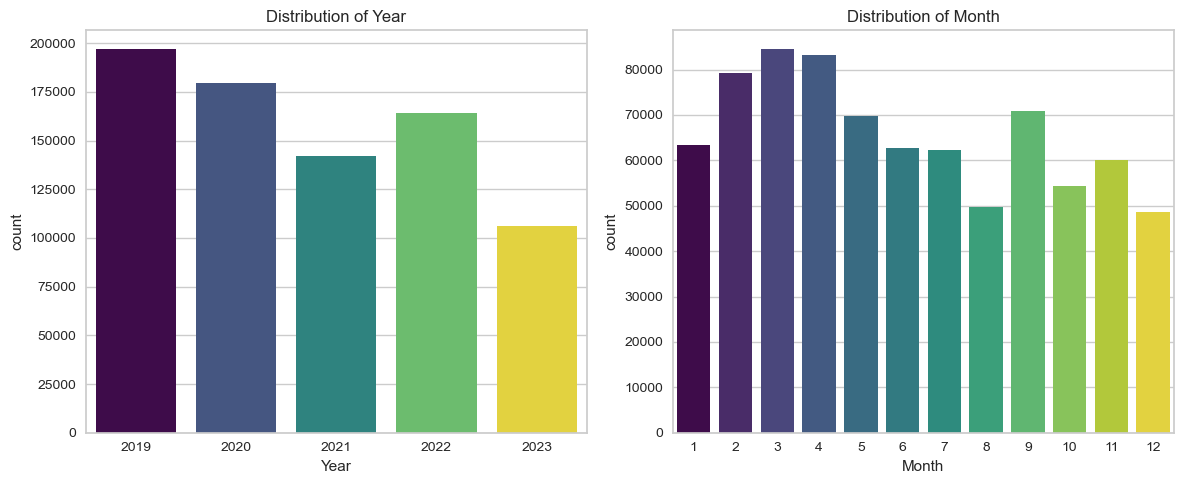

In [33]:
# Visualize distributions for 'Year' and 'Month' using histograms/countplots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='Year', data=df, palette='viridis', hue='Year', legend=False)
plt.title('Distribution of Year')

plt.subplot(1, 2, 2)
sns.countplot(x='Month', data=df, palette='viridis', hue='Month', legend=False)
plt.title('Distribution of Month')

plt.tight_layout()
plt.show()

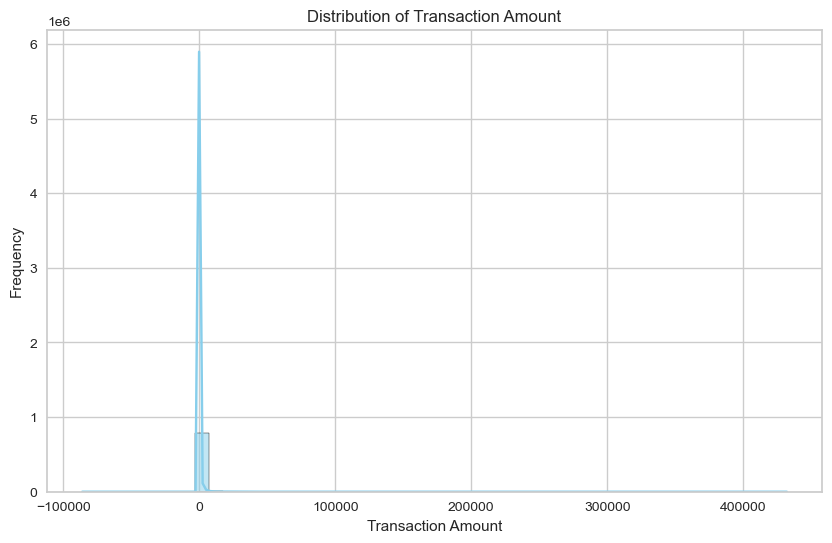

In [34]:
# Visualize 'TrnxAmount' with a histogram and KDE plot
plt.figure(figsize=(10, 6))
sns.histplot(df['TrnxAmount'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Transaction Amount')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()

<Figure size 1000x1000 with 0 Axes>

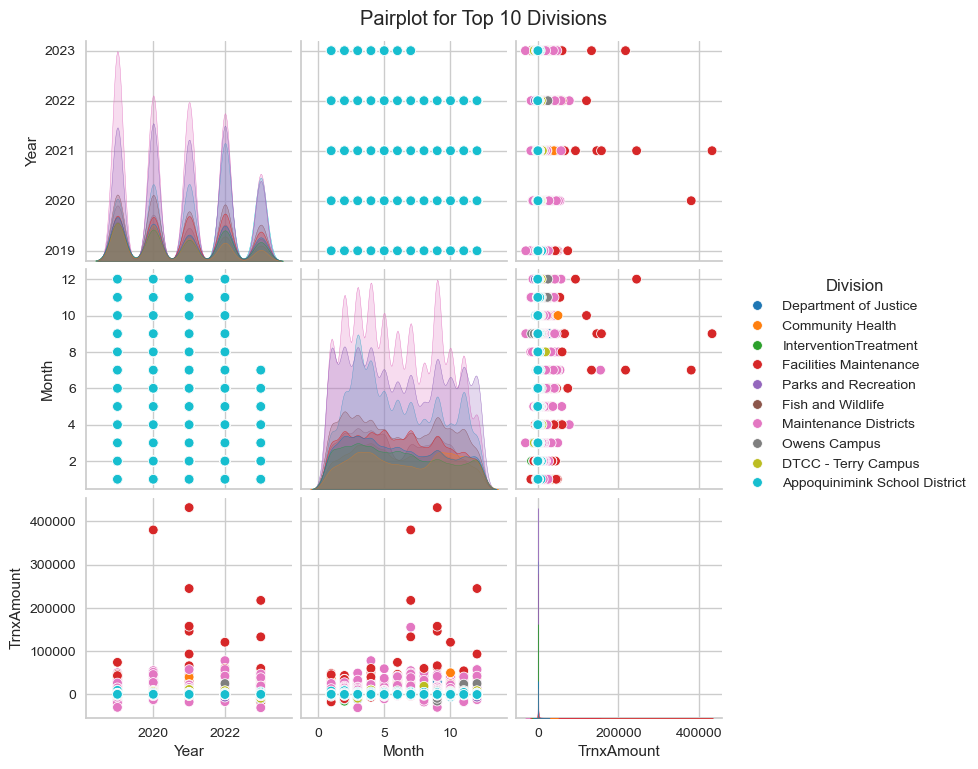

In [35]:
# Get the top 10 unique 'Division' values
top_10_divisions = df['Division'].value_counts().nlargest(10).index.tolist()

df_top_10_divisions = df[df['Division'].isin(top_10_divisions)]

plt.figure(figsize=(10, 10))
sns.pairplot(df_top_10_divisions, hue='Division', palette='tab10')
plt.suptitle('Pairplot for Top 10 Divisions', y=1.02)
plt.show()

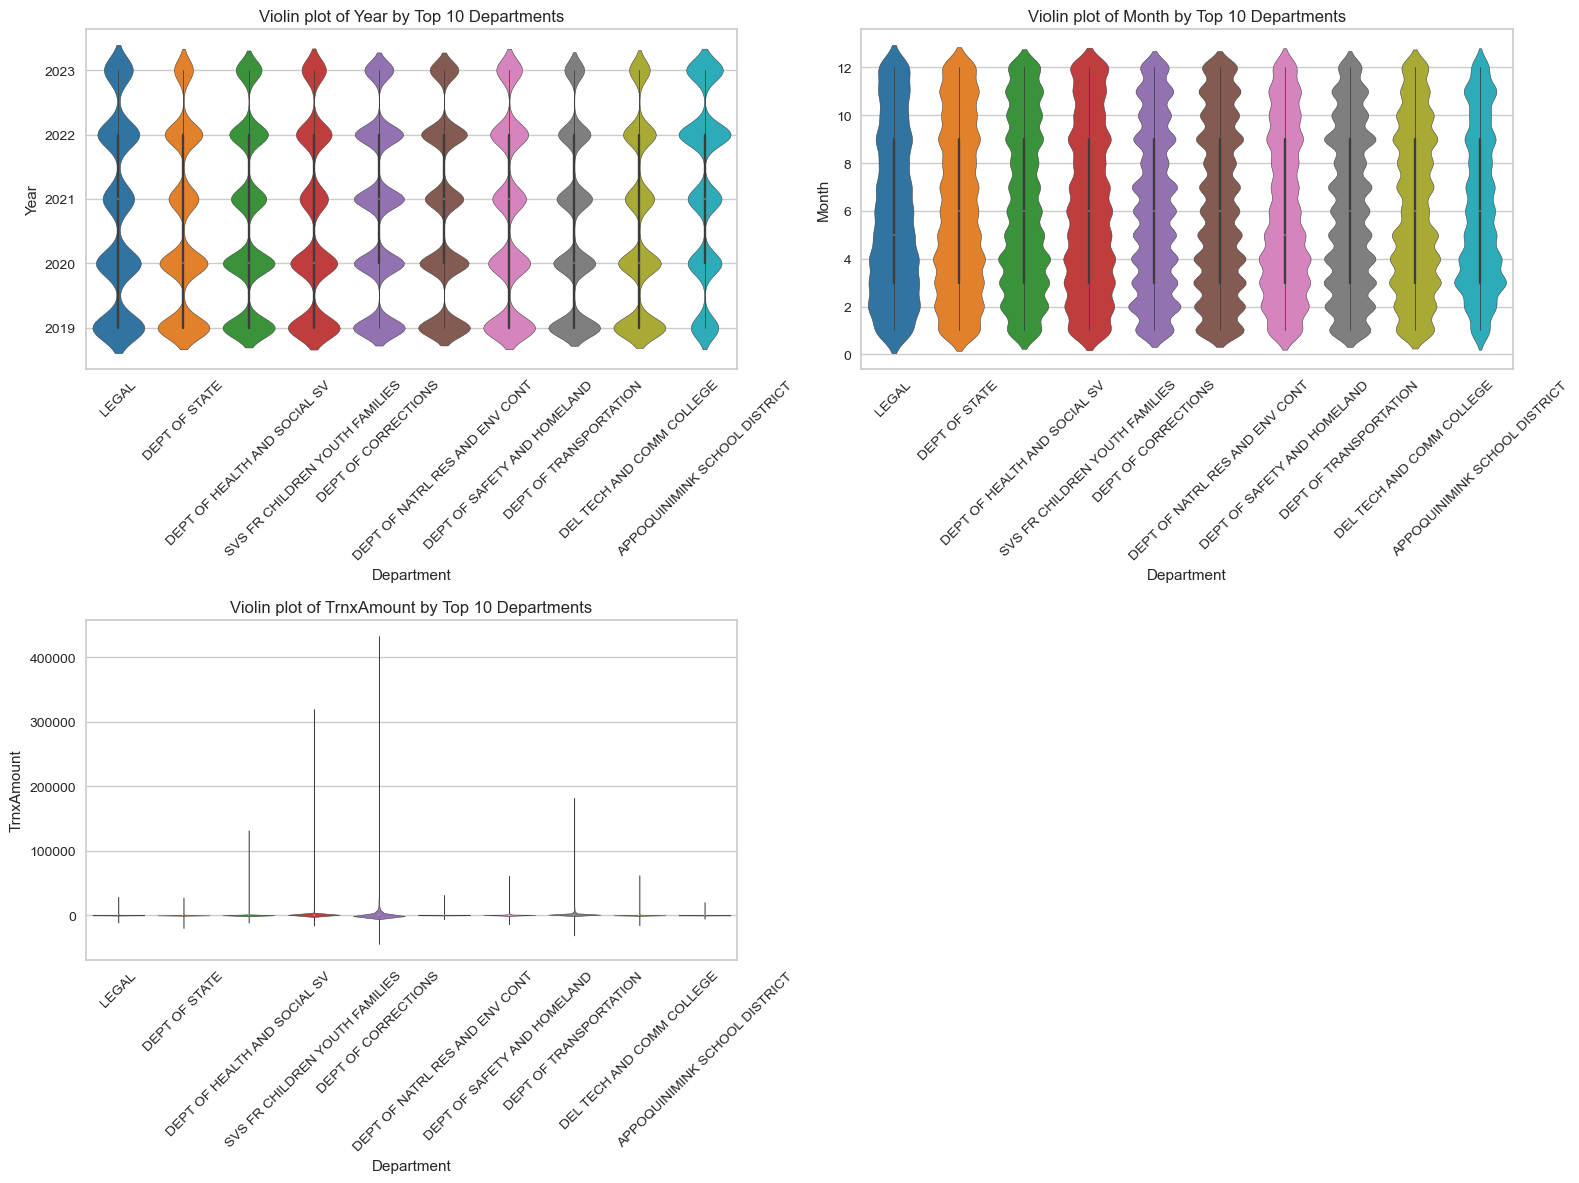

In [36]:
#top 10 unique 'Department' values
top_10_departments = df['Department'].value_counts().nlargest(10).index.tolist()

#Filter the DataFrame to include only the top 10 departments
df_top_10_departments = df[df['Department'].isin(top_10_departments)].copy()

# Subplots with violin plots based on top 10 Departments
num_plots = len(num_cols)
cols = 2
rows = (num_plots // cols) + (num_plots % cols > 0)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 8, rows * 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.violinplot(data=df_top_10_departments, x='Department', y=col, hue='Department', palette='tab10', ax=axes[i], legend=False)
    axes[i].set_title(f'Violin plot of {col} by Top 10 Departments')
    axes[i].set_xlabel('Department')
    axes[i].set_ylabel(col)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

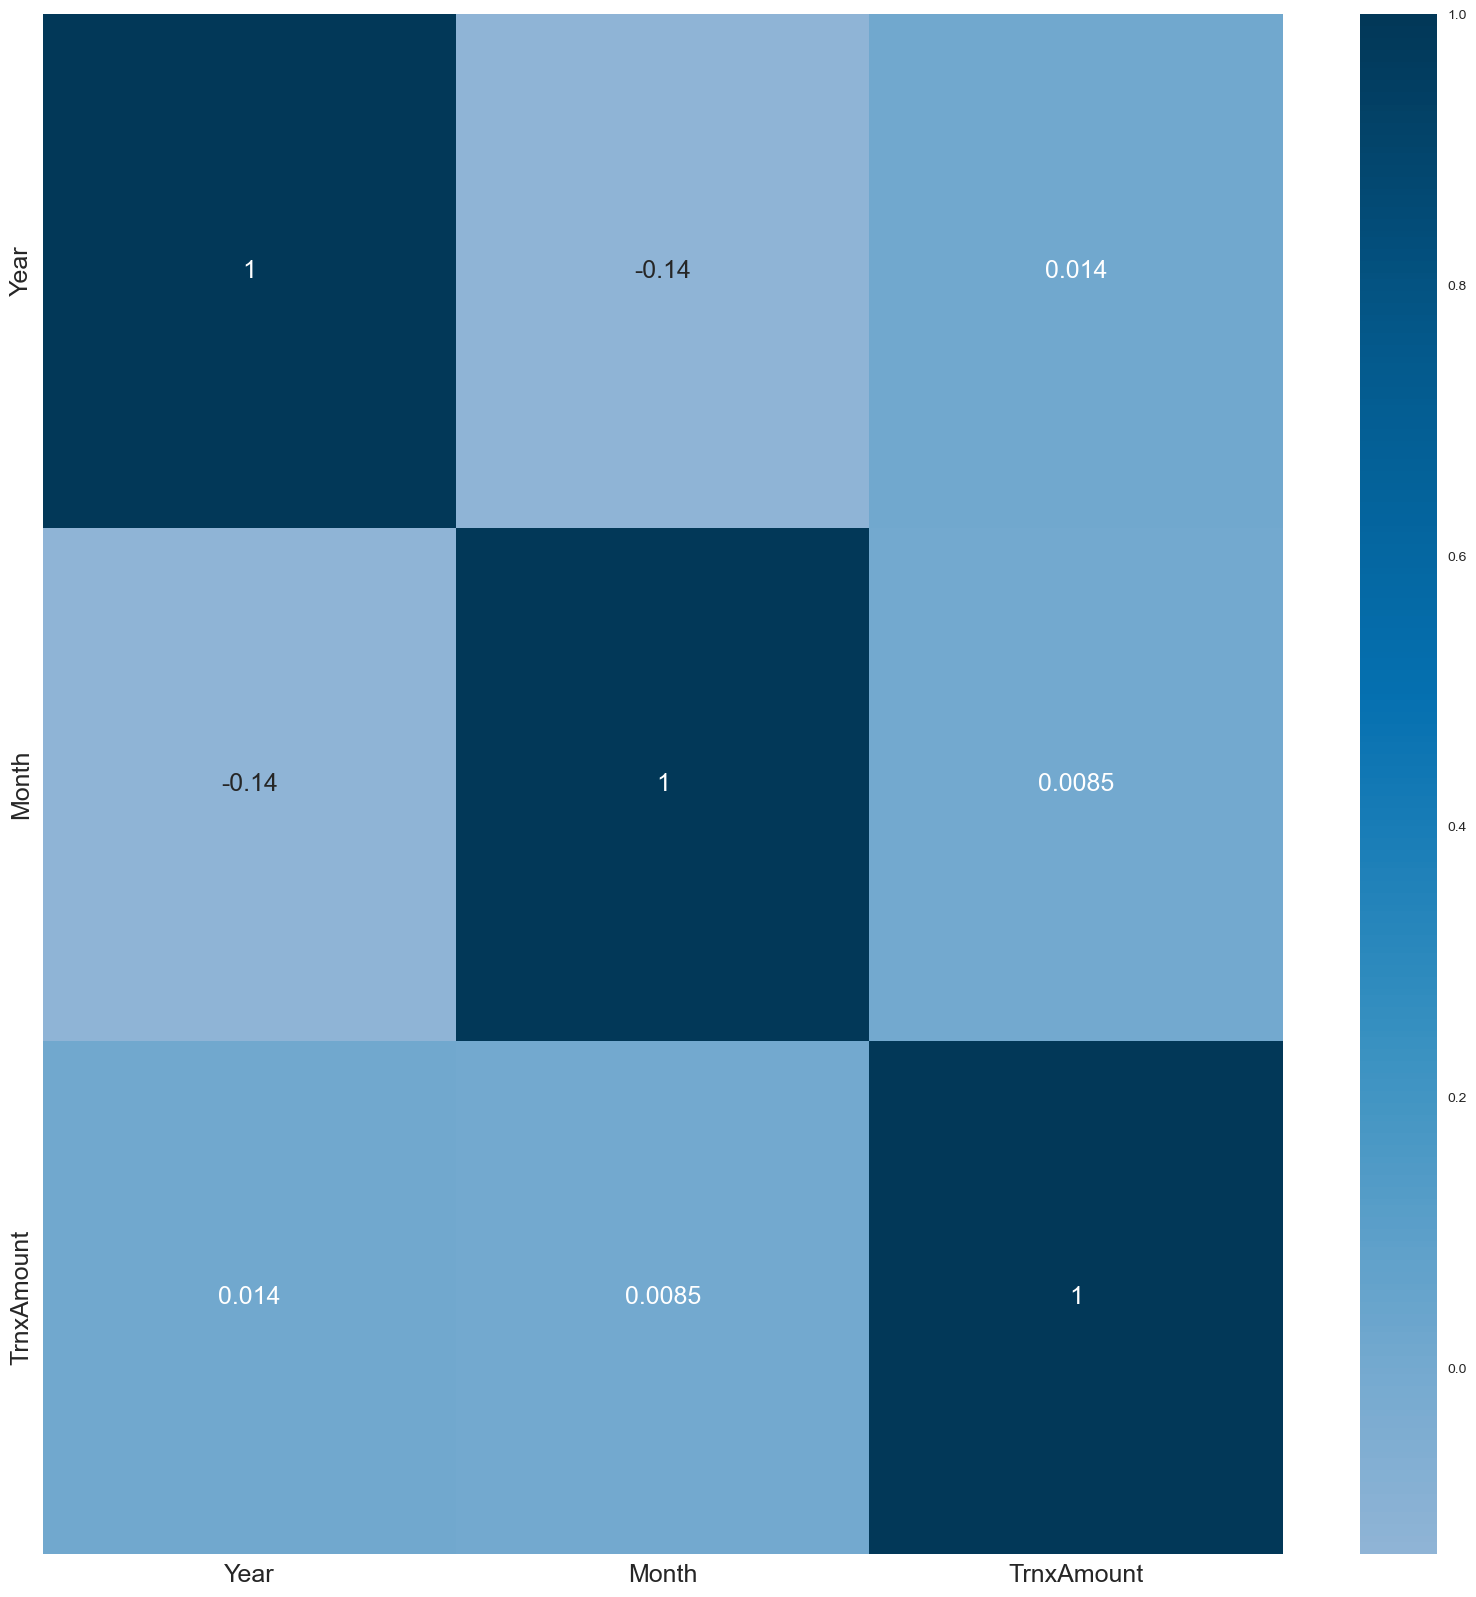

In [37]:
# Creating a correlation heatmap to visualize the correlation among the features
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corrmat = numeric_df.corr()
plt.figure(figsize=(20,20))
sns.heatmap(corrmat, annot=True, cmap='PuBu', center=0, annot_kws={"size": 18})
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.show()

**Encoding categorical entries**

In [39]:
# Making a copy of the dataset before clustering
df_clustering = df.copy()

In [40]:
# Obtaining the list of categorical variables in the dataset
cat_cols = (df_clustering.dtypes == 'object')
object_cols = list(cat_cols[cat_cols].index)
print("Categorical variables in the dataset:", object_cols)

Categorical variables in the dataset: ['Department', 'Division', 'Merchant', 'TranxDescription', 'TranxDate']


In [41]:
import pandas as pd

# Cleaning the Dates
if 'TranxDate' in df_clustering.columns:
    df_clustering['TranxDate'] = pd.to_datetime(df_clustering['TranxDate'], format='mixed', errors='coerce')
    df_clustering['Month'] = df_clustering['TranxDate'].dt.month
    df_clustering['DayOfWeek'] = df_clustering['TranxDate'].dt.dayofweek
    # Drop the original date column now that we have features
    df_clustering = df_clustering.drop(columns=['TranxDate'])


# Excluding 'TranxDescription' since it's too unique
target_cols = ['Department', 'Division', 'Merchant']

# Frequency Encoding 
for col in target_cols:
    if col in df_clustering.columns:
        # Replace text with the count of how often it appears
        freq_map = df_clustering[col].value_counts()
        df_clustering[col] = df_clustering[col].map(freq_map)
    else:
        print(f"Warning: {col} not found in DataFrame, skipping...")

# Dropping TranxDescription if it still exists 
if 'TranxDescription' in df_clustering.columns:
    df_clustering = df_clustering.drop(columns=['TranxDescription'])

# Fill any missing values created by the cleaning
df_final = df_clustering.fillna(0)

print("Dataframe shape:", df_final.shape)
print(df_final.head())

Dataframe shape: (788521, 7)
   Year  Month  Department  Division  Merchant  TrnxAmount  DayOfWeek
0  2019      6        3690      1422      1086        9.85          4
1  2019      7        3690      1422       897       15.00          1
2  2019      7        3690      1422       452      170.31          6
3  2019      6        3690      1422        14     3427.80          5
4  2019      6        3690      1422       709      113.06          2


In [42]:
# Standardizing the data
scaler = StandardScaler()
scaler.fit(df_final)
df_clustering = pd.DataFrame(scaler.transform(df_final),columns= df_final.columns )
print("Standardization complete")

Standardization complete


In [43]:
# Data after encoding and scaling
df_clustering.head()

,Year,Month,Department,Division,Merchant,TrnxAmount,DayOfWeek
0,-1.266636,-0.216265,-1.3387,-0.741918,-0.076591,-0.168662,0.971462
1,-1.266636,0.075540,-1.3387,-0.741918,-0.139144,-0.166588,-0.869672
2,-1.266636,0.075540,-1.3387,-0.741918,-0.286424,-0.104038,2.198885
3,-1.266636,-0.216265,-1.3387,-0.741918,-0.431387,1.207903,1.585173
4,-1.266636,-0.216265,-1.3387,-0.741918,-0.201365,-0.127095,-0.255961


**Dimensionality Reduction**

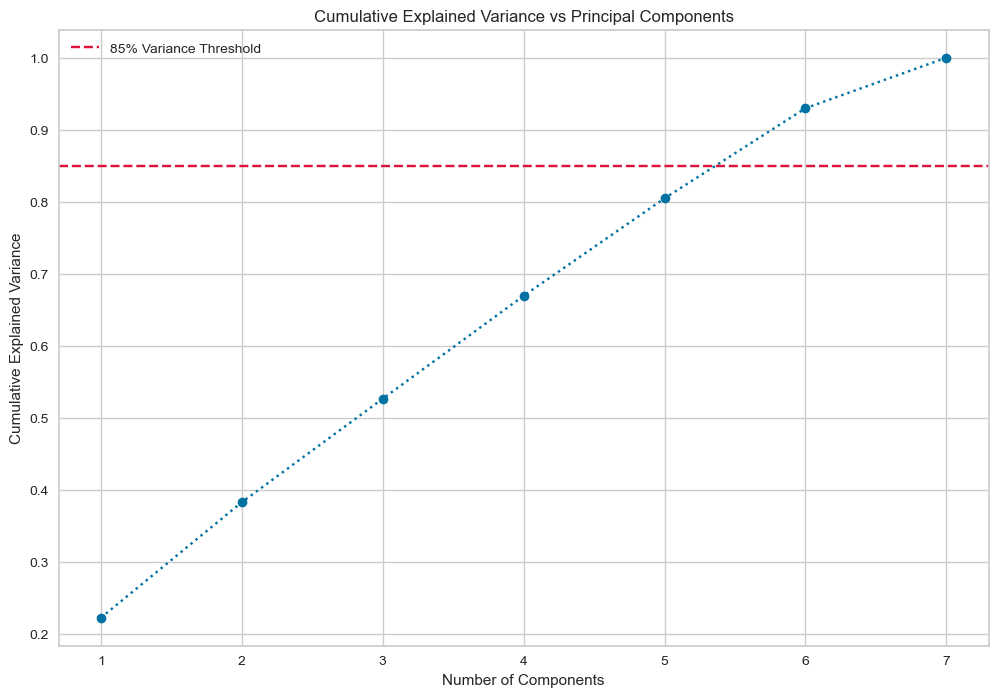

In [45]:
# Fit PCA
pca = PCA()
pca.fit(df_clustering)

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_

# Cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(12, 8))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle=':', color='b')
plt.axhline(y=0.85, color="crimson", linestyle= "--", label="85% Variance Threshold")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance vs Principal Components")
plt.legend()
plt.show()

6 principal components are required to explain at least 85% of the total variance in this dataset.

Number of components explaining more than 10% variance: 6


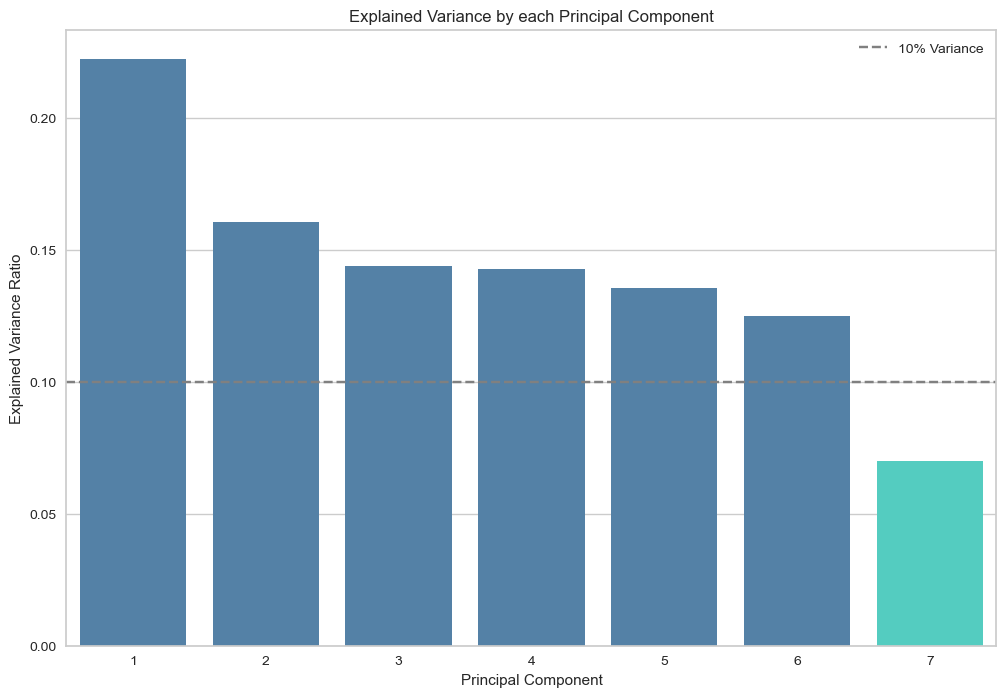

In [46]:
# Finding the number of components that explain more than 10% of the variance individually
pca = PCA(n_components=None)
pca.fit(df_clustering)

explained_variance_ratios = pca.explained_variance_ratio_

n_components = sum(explained_variance_ratios > 0.1)
print(f"Number of components explaining more than 10% variance: {n_components}")

threshold = 0.1
above_threshold = explained_variance_ratios > threshold

# Bar plot
plt.figure(figsize=(12, 8))
sns.barplot(
    x=np.arange(1, len(explained_variance_ratios) + 1),
    y=explained_variance_ratios,
    hue=["steelblue" if x else "maroon" for x in above_threshold],
    palette=["steelblue", "turquoise"],
    legend=False
)
plt.axhline(y=threshold, color="gray", linestyle="--", label="10% Variance")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance by each Principal Component")
plt.legend()
plt.show()

In [47]:
# Initiating PCA to reduce the dimensions to 3
pca = PCA(n_components=3)
pca.fit(df_clustering)
PCA_df = pd.DataFrame(pca.transform(df_clustering), columns=(["PC1","PC2", "PC3"]))
PCA_df.describe().T
PCA_df.head()

,PC1,PC2,PC3
0,-1.502808,-1.134849,-0.451079
1,-1.316785,-0.875354,0.404114
2,-1.716017,-0.970946,-0.982878
3,-1.595752,-1.082013,0.479028
4,-1.391370,-1.097860,0.174394


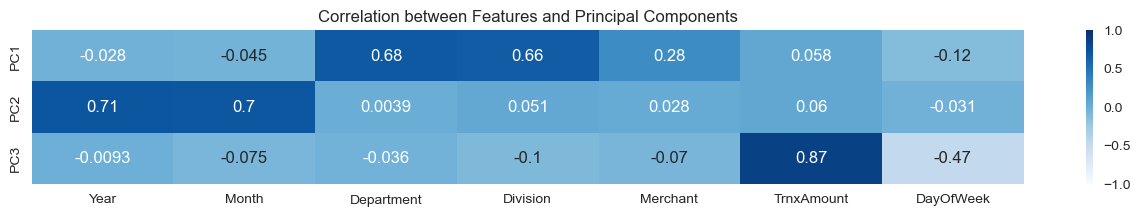

In [48]:
# Calculating the correlation between the original features and the principal components
loadings_df = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2', 'PC3'], index=df_clustering.columns)
loadings_df = loadings_df.T

# Heatmap
plt.figure(figsize=(16, 2))
sns.heatmap(loadings_df, annot=True, cmap="Blues", vmin=-1, vmax=1)
plt.title("Correlation between Features and Principal Components")
plt.show()

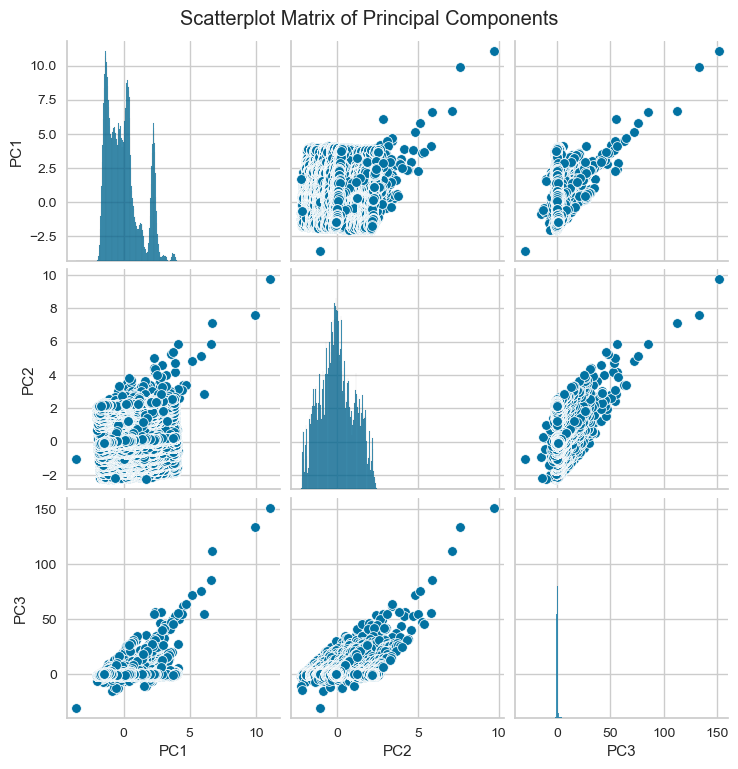

In [49]:
# Scatterplot matrix of the principal components
sns.pairplot(PCA_df)
plt.suptitle("Scatterplot Matrix of Principal Components", y=1.02)
plt.show()

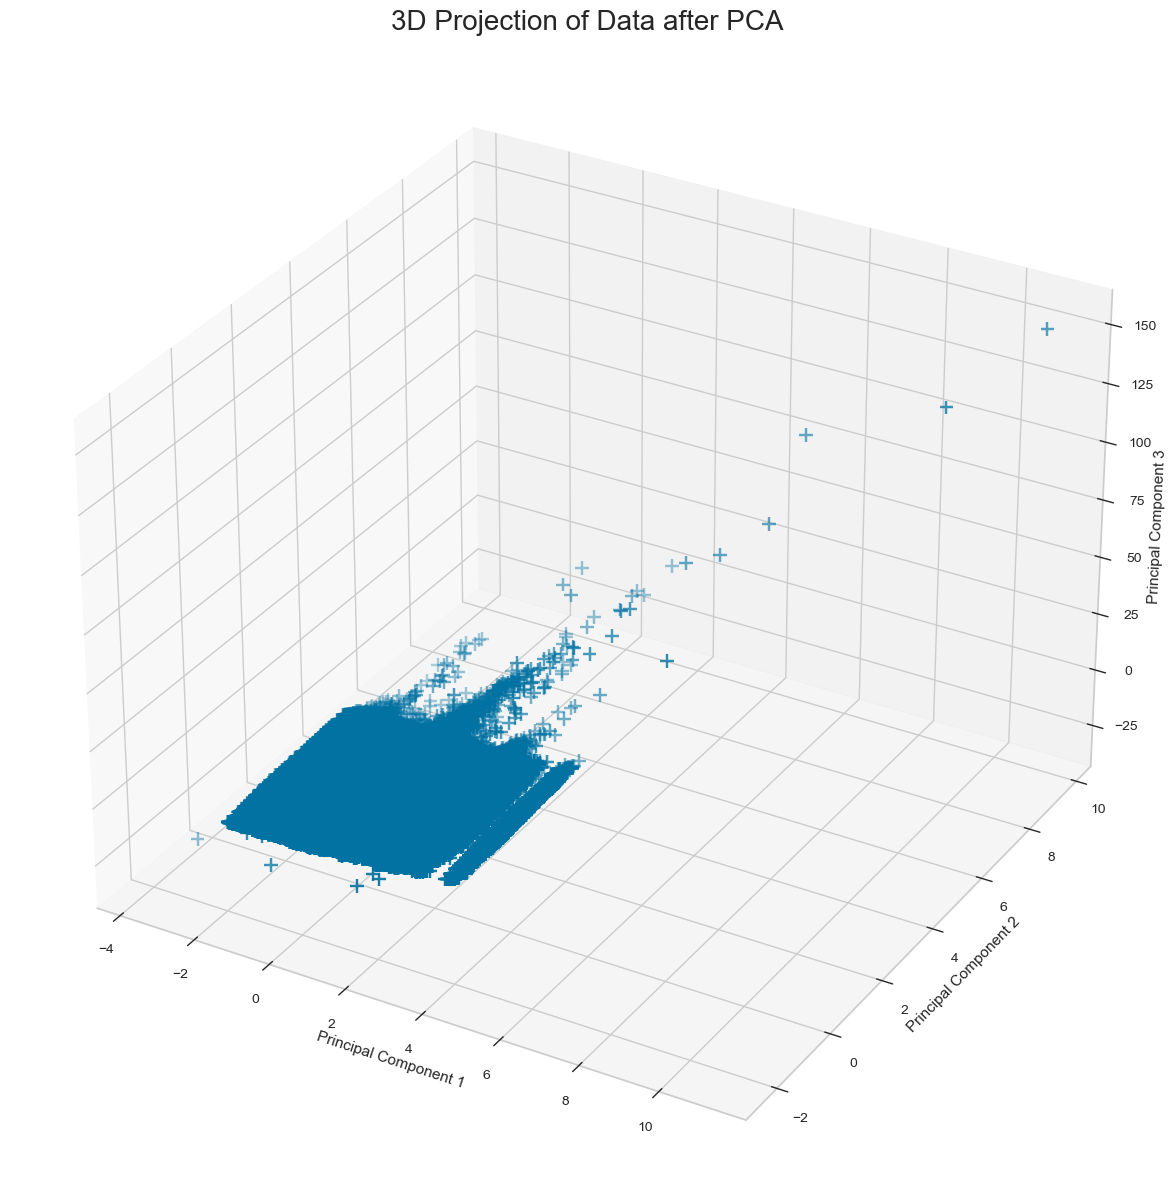

In [50]:
# 3D Projection of the Principal Components
x =PCA_df["PC1"]
y =PCA_df["PC2"]
z =PCA_df["PC3"]

fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(x, y, z, marker='+', s=100)
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.set_title('3D Projection of Data after PCA', fontsize=20)
plt.show()

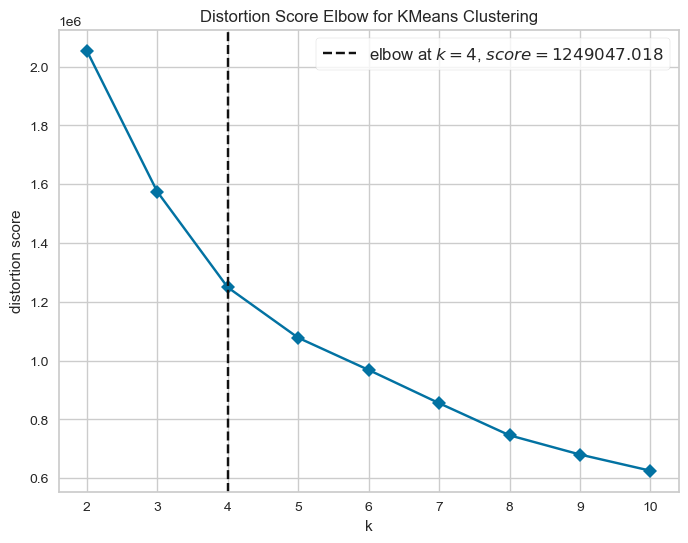

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [51]:
# Elbow method to determine the optimal number of clusters
fig, ax = plt.subplots(figsize=(8, 6))

Elbow_M = KElbowVisualizer(KMeans(random_state=42, n_init=10), k=10, metric='distortion', locate_elbow=True, timings=False, ax=ax, force_model=True)
Elbow_M.fit(PCA_df)
Elbow_M.show()

C:\Users\gamag\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1962: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


Clusters: 2 | Score: 0.2892 (Done)
Clusters: 3 | Score: 0.3150 (Done)


C:\Users\gamag\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1962: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\gamag\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1962: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


Clusters: 4 | Score: 0.2900 (Done)
Clusters: 5 | Score: 0.2780 (Done)


C:\Users\gamag\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1962: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\gamag\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1962: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


Clusters: 6 | Score: 0.2599 (Done)


C:\Users\gamag\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1962: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


Clusters: 7 | Score: 0.2473 (Done)


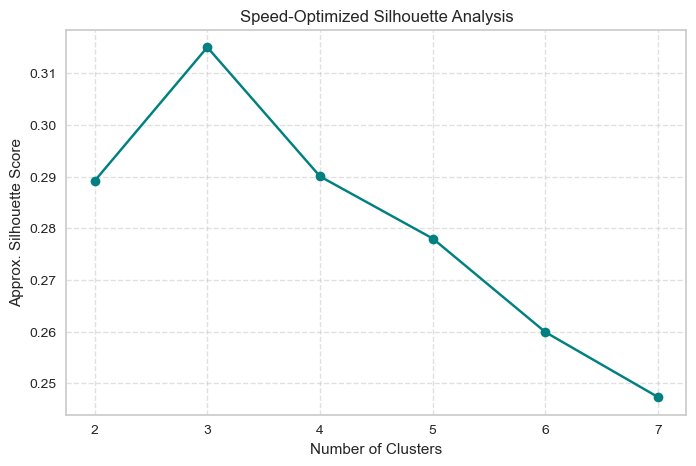

In [81]:
from sklearn.cluster import MiniBatchKMeans

range_n_clusters = list(range(2, 8))

SAMPLE_SIZE = 1000
RANDOM_SEED = 0

silhouette_avg_scores = []

for n_clusters in range_n_clusters:

    kmeans = MiniBatchKMeans(n_clusters=n_clusters,
                             random_state=RANDOM_SEED,
                             batch_size=1024,
                             n_init=3)
    cluster_labels = kmeans.fit_predict(PCA_df)


    if len(PCA_df) > SAMPLE_SIZE:
        indices = np.random.choice(len(PCA_df), SAMPLE_SIZE, replace=False)
        sub_df = PCA_df.iloc[indices]
        sub_labels = cluster_labels[indices]

        silhouette_avg = silhouette_score(sub_df, sub_labels)
    else:
        silhouette_avg = silhouette_score(PCA_df, cluster_labels)

    silhouette_avg_scores.append(silhouette_avg)
    print(f"Clusters: {n_clusters} | Score: {silhouette_avg:.4f} (Done)")


plt.figure(figsize=(8, 5))
plt.plot(range_n_clusters, silhouette_avg_scores, marker='o', color='teal')
plt.xlabel('Number of Clusters')
plt.ylabel('Approx. Silhouette Score')
plt.title('Speed-Optimized Silhouette Analysis')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### **Clustering**

In [118]:
# Initiating the K-Means algorithm with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42)

# Fitting the model and predicting the clusters
yhat_kmeans = kmeans.fit_predict(PCA_df)
yhat_kmeans = yhat_kmeans + 1

# Adding the clusters to the dataframes
PCA_df["Clusters"] = yhat_kmeans
df["Clusters"] = yhat_kmeans

In [122]:
SAMPLE_SIZE = 10000
RANDOM_SEED = 0

if len(PCA_df) > SAMPLE_SIZE:
    indices = np.random.choice(len(PCA_df), SAMPLE_SIZE, replace=False)
    sub_df = PCA_df.iloc[indices]
    sub_labels = yhat_kmeans[indices]
    sil_score = silhouette_score(sub_df, sub_labels)
else:
    sil_score = silhouette_score(PCA_df, yhat_kmeans)

print(f'Silhouette Score: {sil_score:.2f}')

Silhouette Score: 0.45


In [124]:
PCA_df_sampled = PCA_df.sample(n=10000, random_state=42)

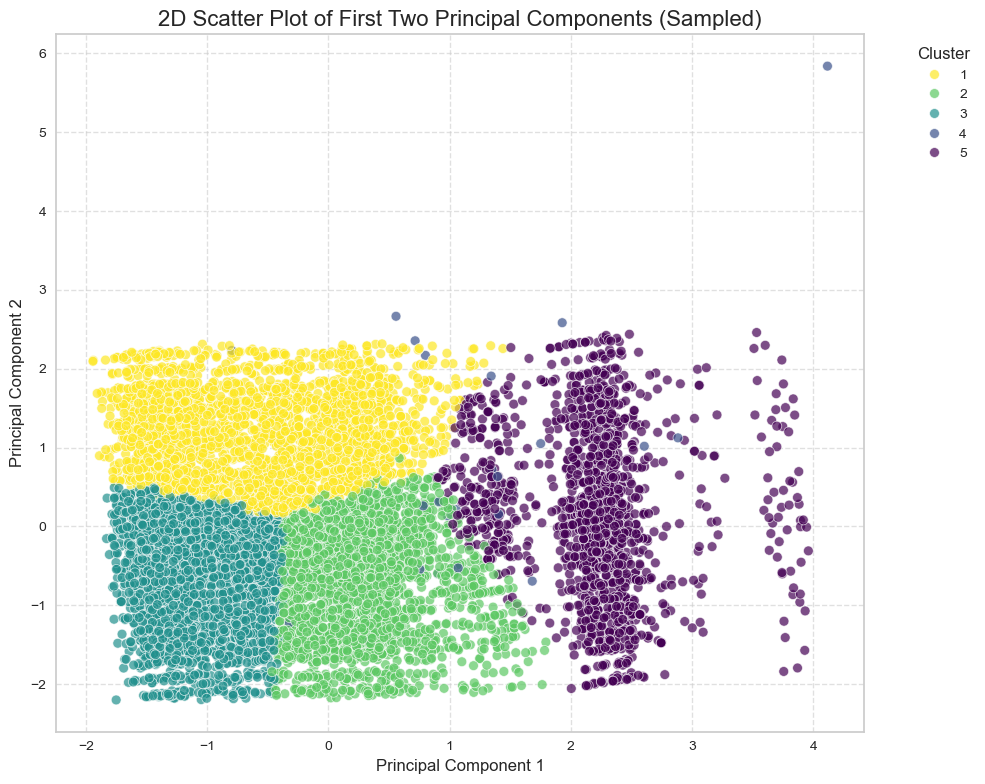

In [126]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Clusters', data=PCA_df_sampled, palette='viridis_r', s=50, alpha=0.7)
plt.title('2D Scatter Plot of First Two Principal Components (Sampled)', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

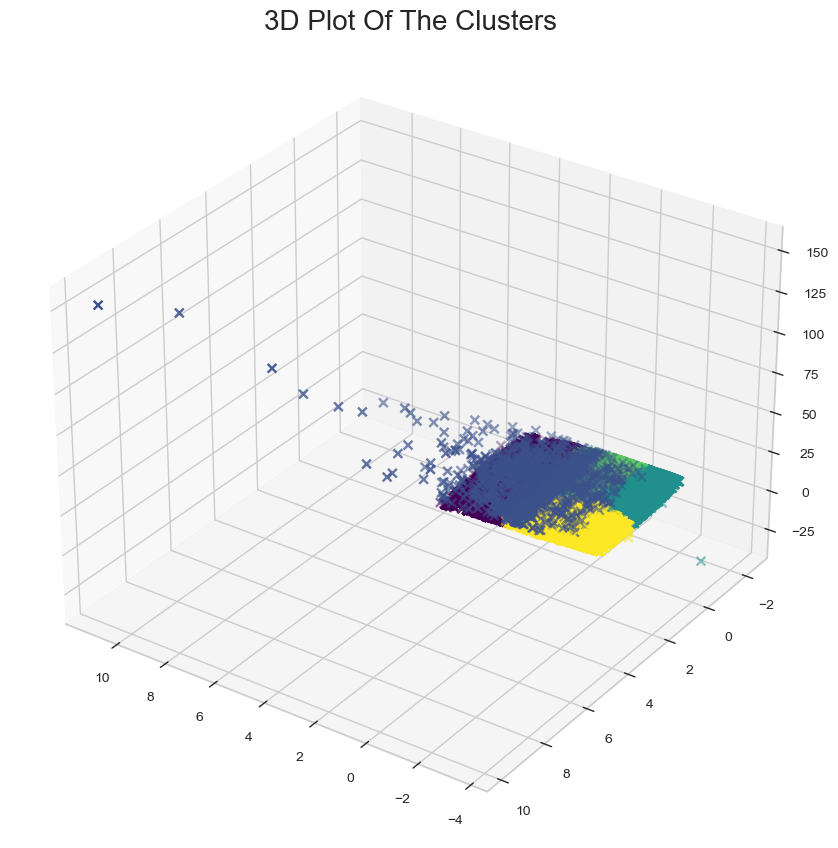

In [128]:
# Plotting the clusters in 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_axes([0, 0, 1, 1], projection='3d')
ax.scatter(x, y, z, s=40, c=df["Clusters"], marker='x', cmap='viridis_r')
ax.view_init(elev=30, azim = 125)
ax.set_title("3D Plot Of The Clusters", fontsize=20)

plt.show()

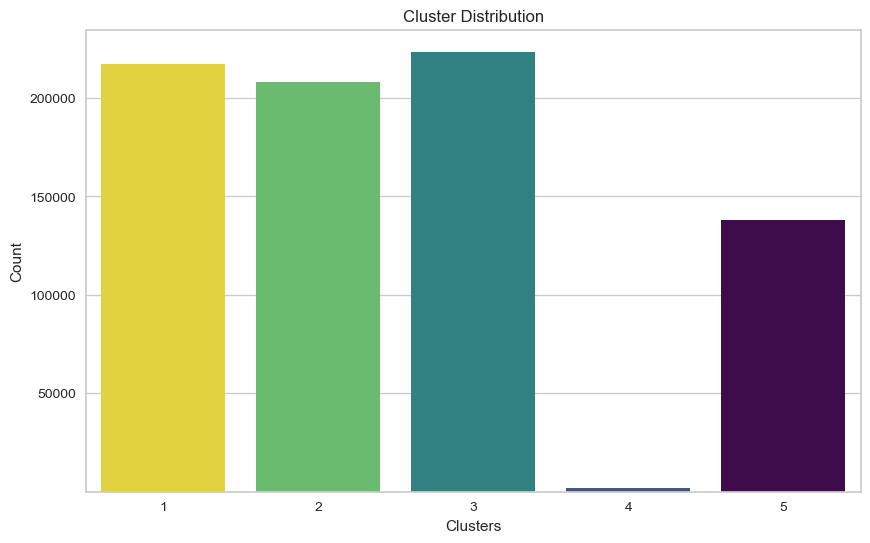

In [130]:
# Barplot to visualise the cluster counts
plt.figure(figsize=(10, 6))
pl = sns.countplot(x="Clusters", hue="Clusters", data=df, palette='viridis_r', legend=False)
pl.set_title('Cluster Distribution')
pl.set_xlabel('Clusters')
pl.set_ylabel('Count')
pl.set_ylim(40, pl.get_ylim()[1])

plt.show()

### **Cluster Analysis**

Scatterplot with the clusters


<Figure size 800x550 with 0 Axes>

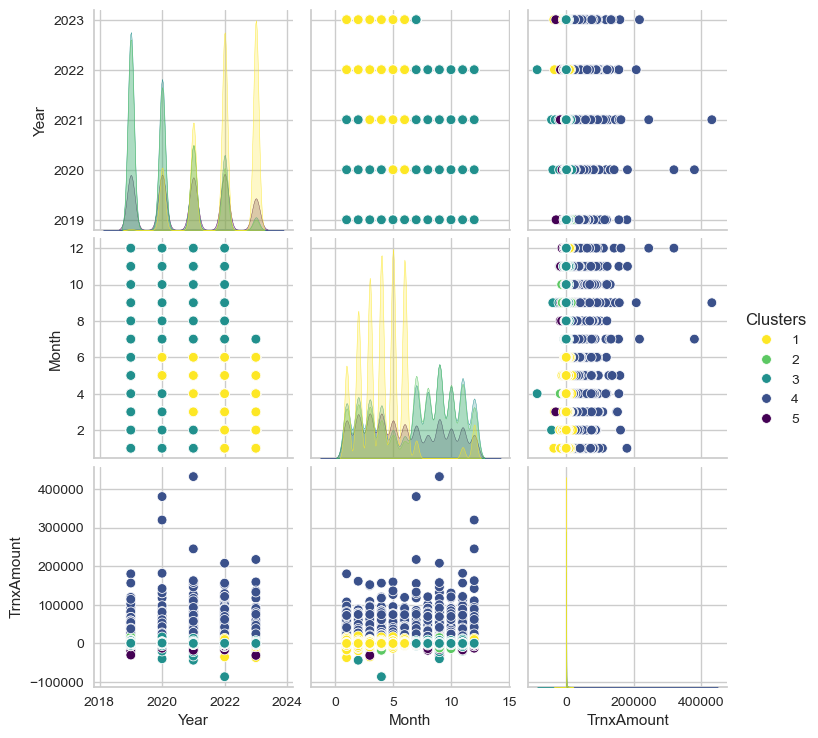

In [133]:
# Scatterplot matrix of the original features with the clusters
print("Scatterplot with the clusters")
plt.figure()
sns.pairplot(df, hue='Clusters', palette='viridis_r')
plt.show()

In [134]:
print(f"Number of unique values in 'Department': {df['Department'].nunique()}")
print(f"Number of unique values in 'Division': {df['Division'].nunique()}")

Number of unique values in 'Department': 68
Number of unique values in 'Division': 304


C:\Users\gamag\AppData\Local\Temp\ipykernel_7544\4051225583.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_departments.index, y=top_departments.values, palette='viridis')


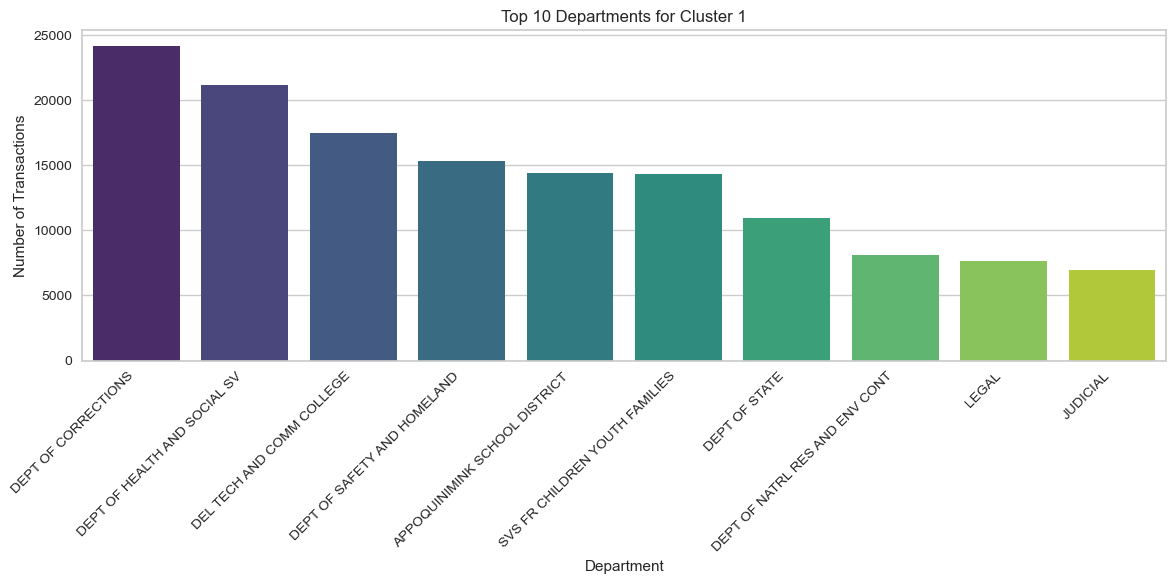

C:\Users\gamag\AppData\Local\Temp\ipykernel_7544\4051225583.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_departments.index, y=top_departments.values, palette='viridis')


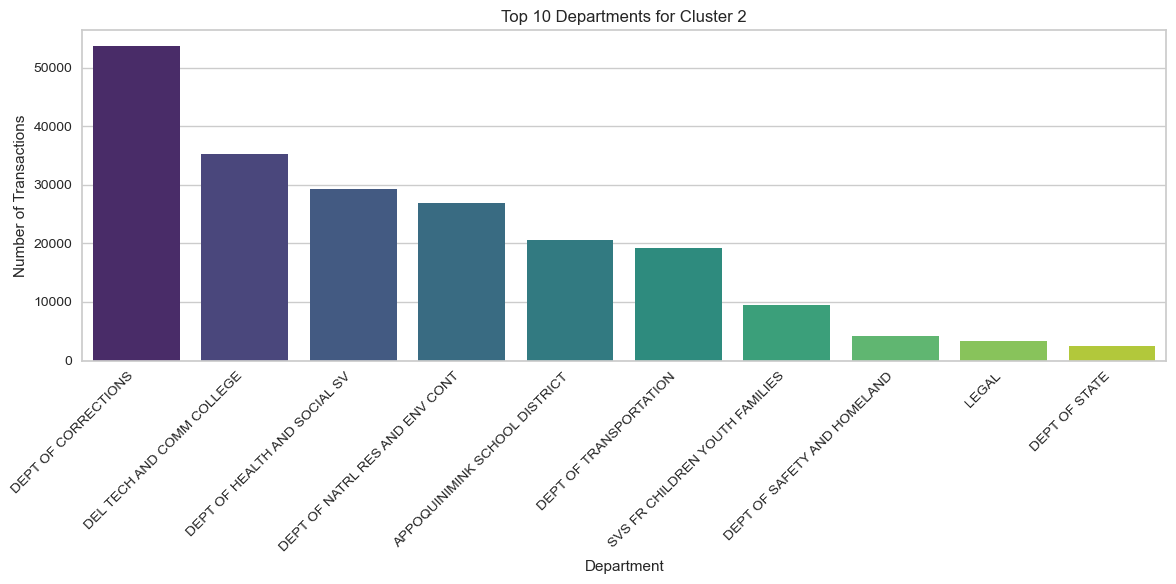

C:\Users\gamag\AppData\Local\Temp\ipykernel_7544\4051225583.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_departments.index, y=top_departments.values, palette='viridis')


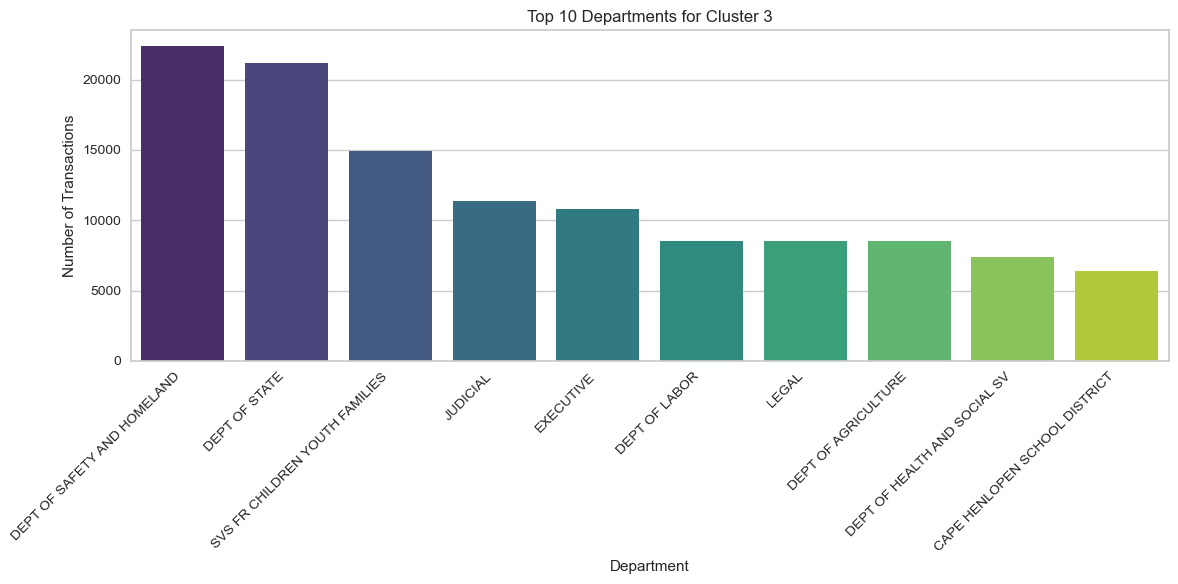

C:\Users\gamag\AppData\Local\Temp\ipykernel_7544\4051225583.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_departments.index, y=top_departments.values, palette='viridis')


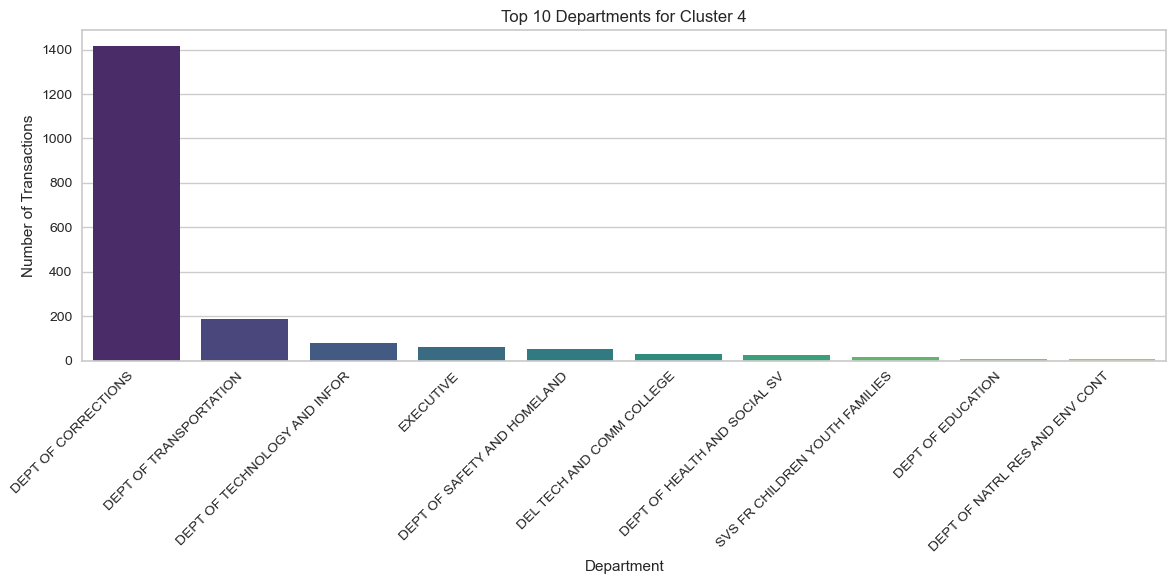

C:\Users\gamag\AppData\Local\Temp\ipykernel_7544\4051225583.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_departments.index, y=top_departments.values, palette='viridis')


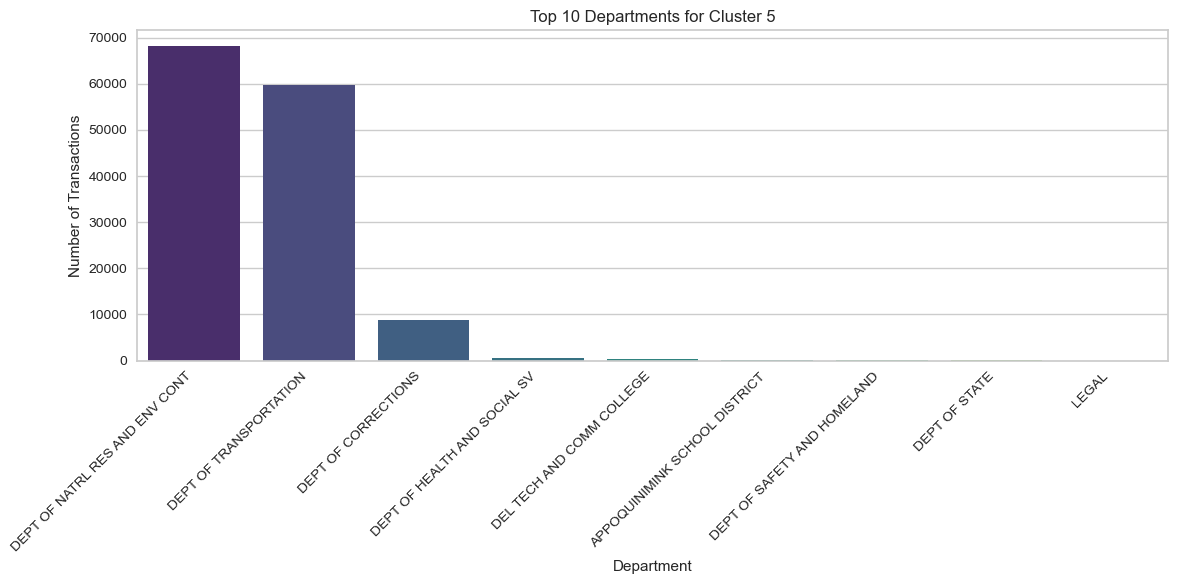

In [137]:
N = 10

unique_clusters = df['Clusters'].unique()
unique_clusters.sort() # Sort clusters for consistent order

for cluster_id in unique_clusters:
    plt.figure(figsize=(12, 6))
    # Filter data for the current cluster
    cluster_df = df[df['Clusters'] == cluster_id]

    # Get top N most frequent departments for this cluster
    top_departments = cluster_df['Department'].value_counts().nlargest(N)

    # Create a bar plot
    sns.barplot(x=top_departments.index, y=top_departments.values, palette='viridis')
    plt.title(f'Top {N} Departments for Cluster {cluster_id}')
    plt.xlabel('Department')
    plt.ylabel('Number of Transactions')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

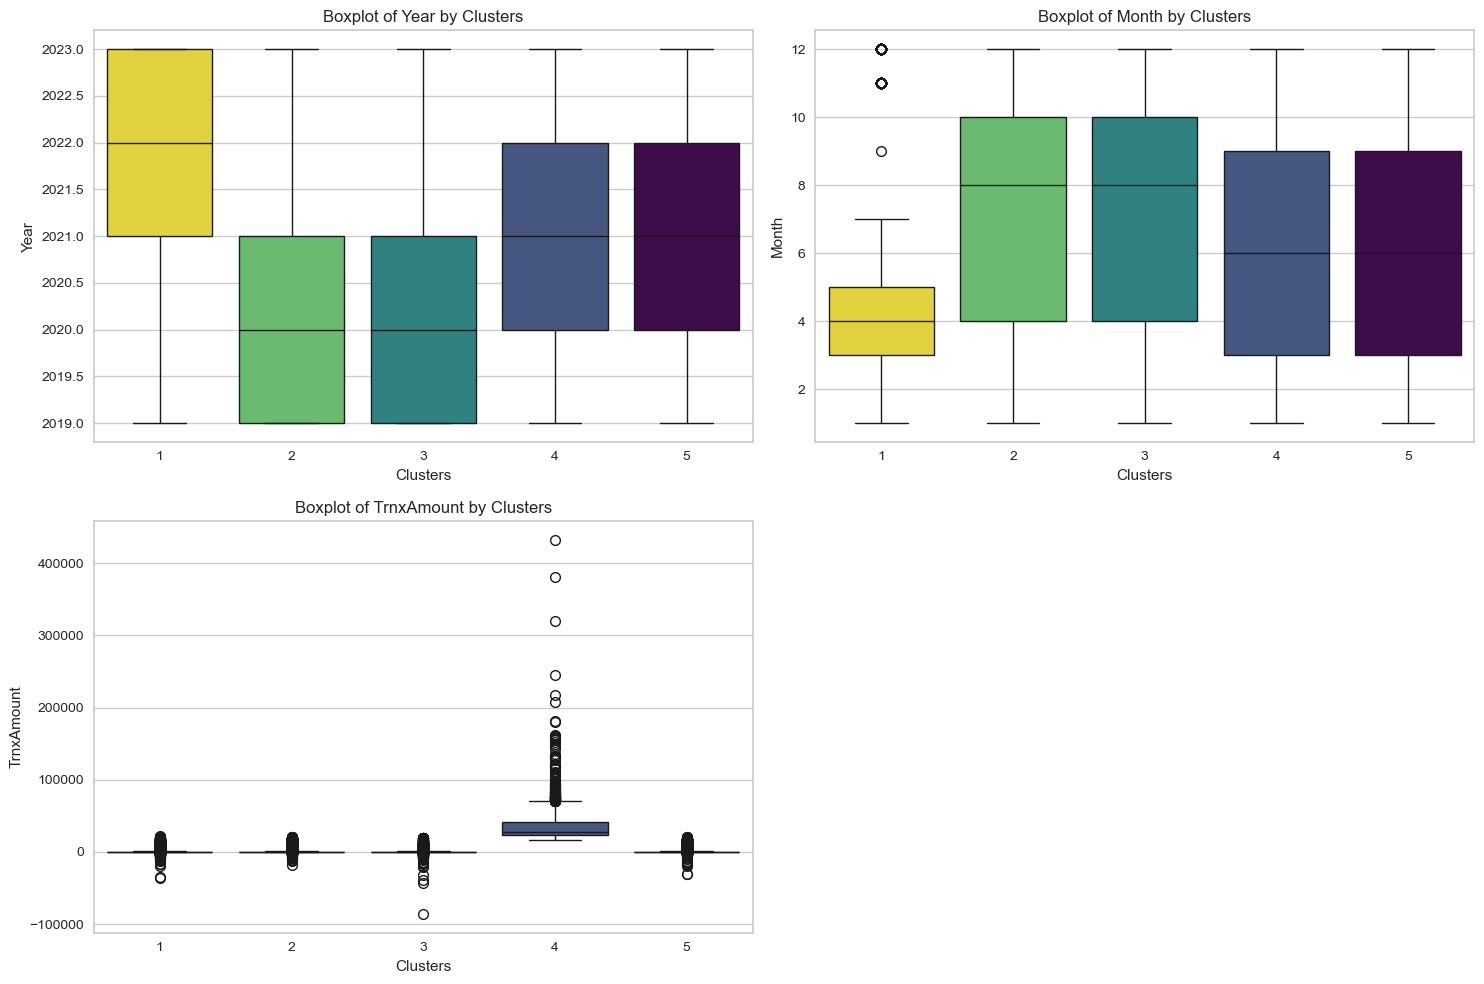

In [139]:
# Visualising the numerical features by clusters
box_cols = ['Year', 'Month', 'TrnxAmount']

n_cols = 2
n_rows = int(np.ceil(len(box_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(box_cols):
    sns.boxplot(x=df["Clusters"], y=df[col], ax=axes[i], hue=df["Clusters"], palette='viridis_r',legend=False)
    axes[i].set_title(f'Boxplot of {col} by Clusters')

for i in range(len(box_cols), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Supervised Learning

### Regression 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# Suppress warnings
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

#### Dataset link

https://www.kaggle.com/datasets/sukhmandeepsinghbrar/housing-price-dataset

In [4]:
#Importing the Dataset
df = pd.read_csv(r"C:\Users\gamag\Downloads\Housing.csv")

In [5]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7229300521,20141013T000000,231300.0,2,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [7]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580306e+09,5.400886e+05,3.370795,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876570e+09,3.671268e+05,0.930105,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [8]:
# Color palette for visualisations
palette=['#104070','#5299B0', '#79C7E3', '#BFF0FF', 'lightblue', 'steelgray',]
palette

['#104070', '#5299B0', '#79C7E3', '#BFF0FF', 'lightblue', 'steelgray']

In [9]:
# Obtaining the list of categorical variables
cat_cols = (df.dtypes == 'object')
object_cols = list(cat_cols[cat_cols].index)
print("Categorical variables in the dataset:", object_cols)

Categorical variables in the dataset: ['date']


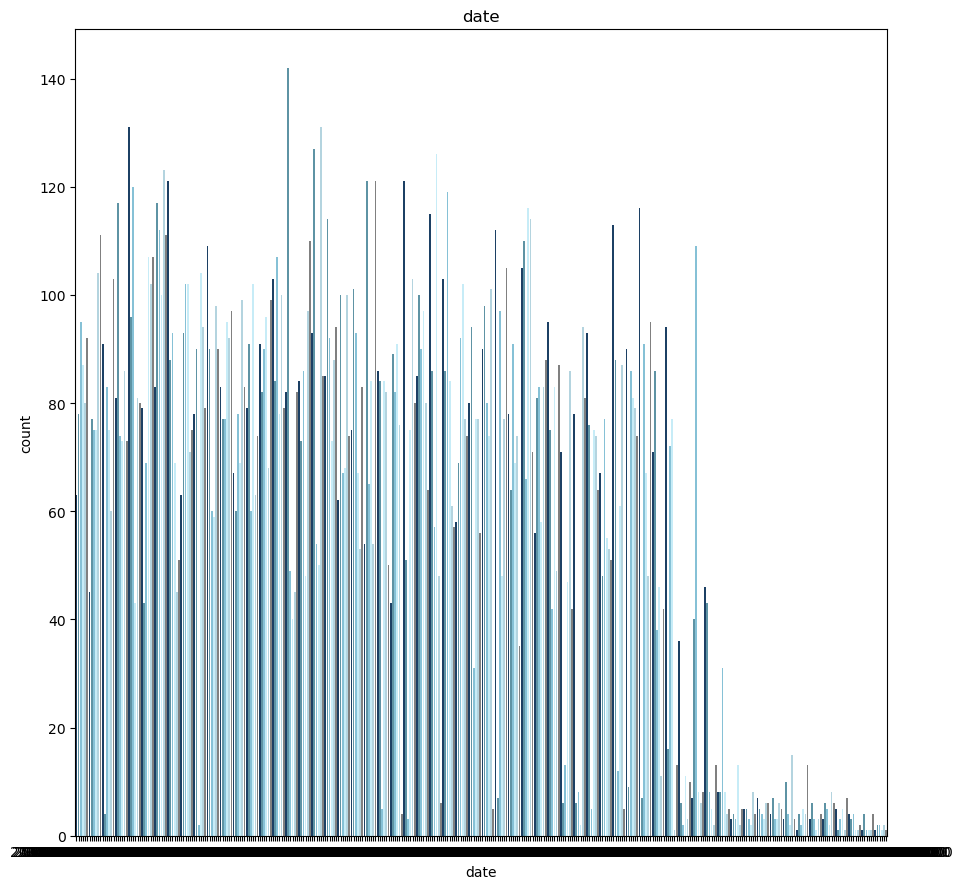

In [10]:
# Visualising the distribution of the categorical columns
cat_cols = ['date']

# Color palette for visualisations 
palette=['#104070','#5299B0', '#79C7E3', '#BFF0FF', 'lightblue', '#808080'] # Replaced 'steelgray' with a valid hex code '#808080'

# Subplot
n_cols = 2
n_rows = (len(cat_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 9 * n_rows))
axes = axes.flatten()
for ax, col in zip(axes, cat_cols):
    sns.countplot(x=col, data=df, ax=ax, palette=palette)
    ax.set_title(f'{col}')
for i in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

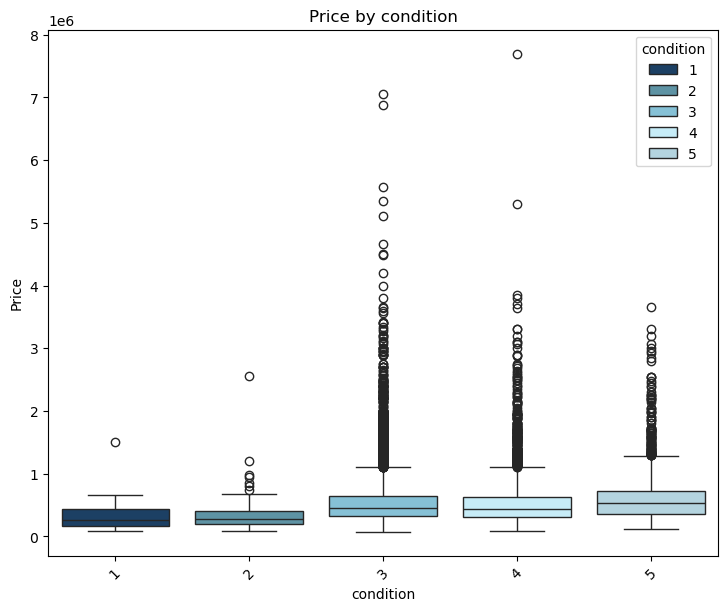

In [11]:
import math # Import the math module

# Visualising the distribution of the price based on condition
cat_cols_for_plot = ['condition'] # Change to 'condition' for this plot

# Subplot
n_cols = 2
n_rows = math.ceil(len(cat_cols_for_plot) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 6 * n_rows), constrained_layout=True)
axes = axes.flatten()

for i, col in enumerate(cat_cols_for_plot):
    sns.boxplot(data=df, x=col, y='price', hue=col, palette=palette, ax=axes[i], dodge=False)
    axes[i].set_title(f'Price by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Price')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(cat_cols_for_plot), len(axes)):
    axes[j].set_visible(False)

plt.show()

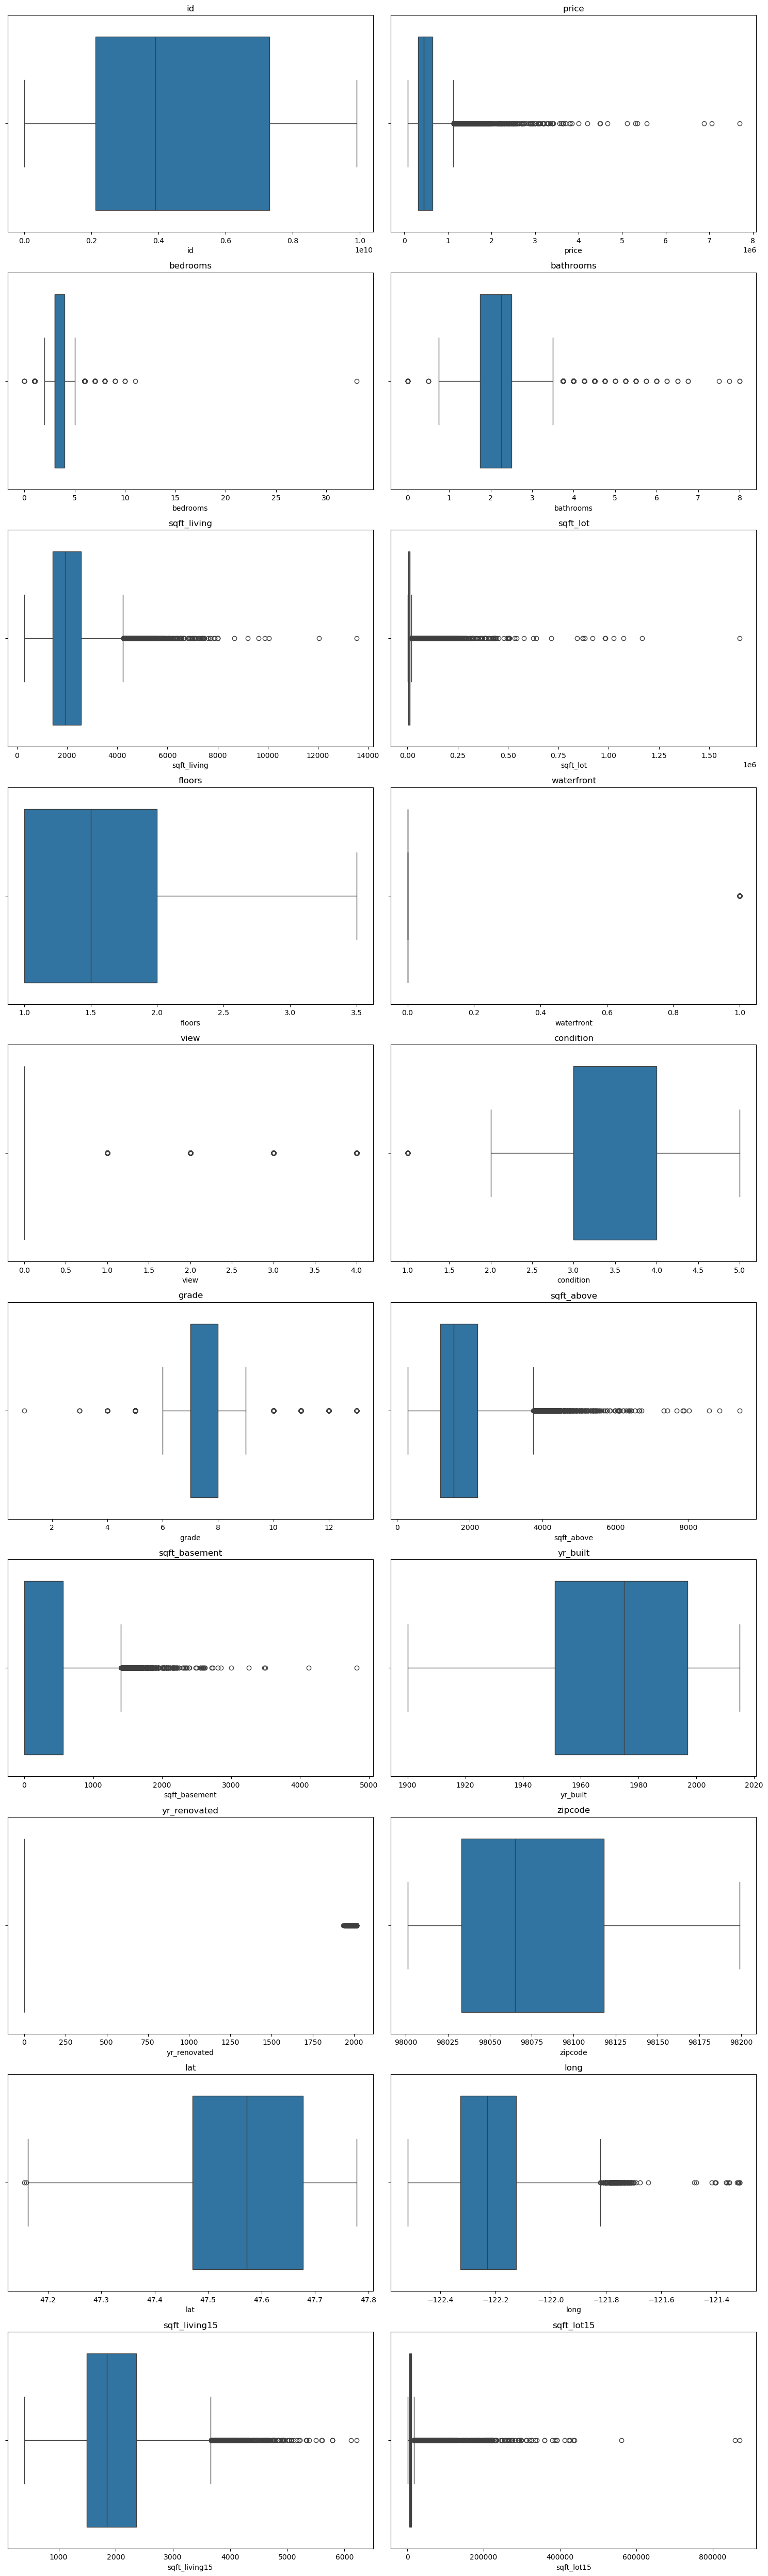

In [12]:
# Visualising the distribution of the numerical columns
num_cols = df.select_dtypes(include=['number']).columns.tolist()


n_cols = 2
n_rows = -(-len(num_cols) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()
for i, column in enumerate(num_cols):
    sns.boxplot(x=df[column], ax=axes[i])
    axes[i].set_title(f'{column}')
    axes[i].set_xlabel(column)
for i in range(len(num_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

Pairplot of the dataset colored by house condition


<Figure size 1200x1000 with 0 Axes>

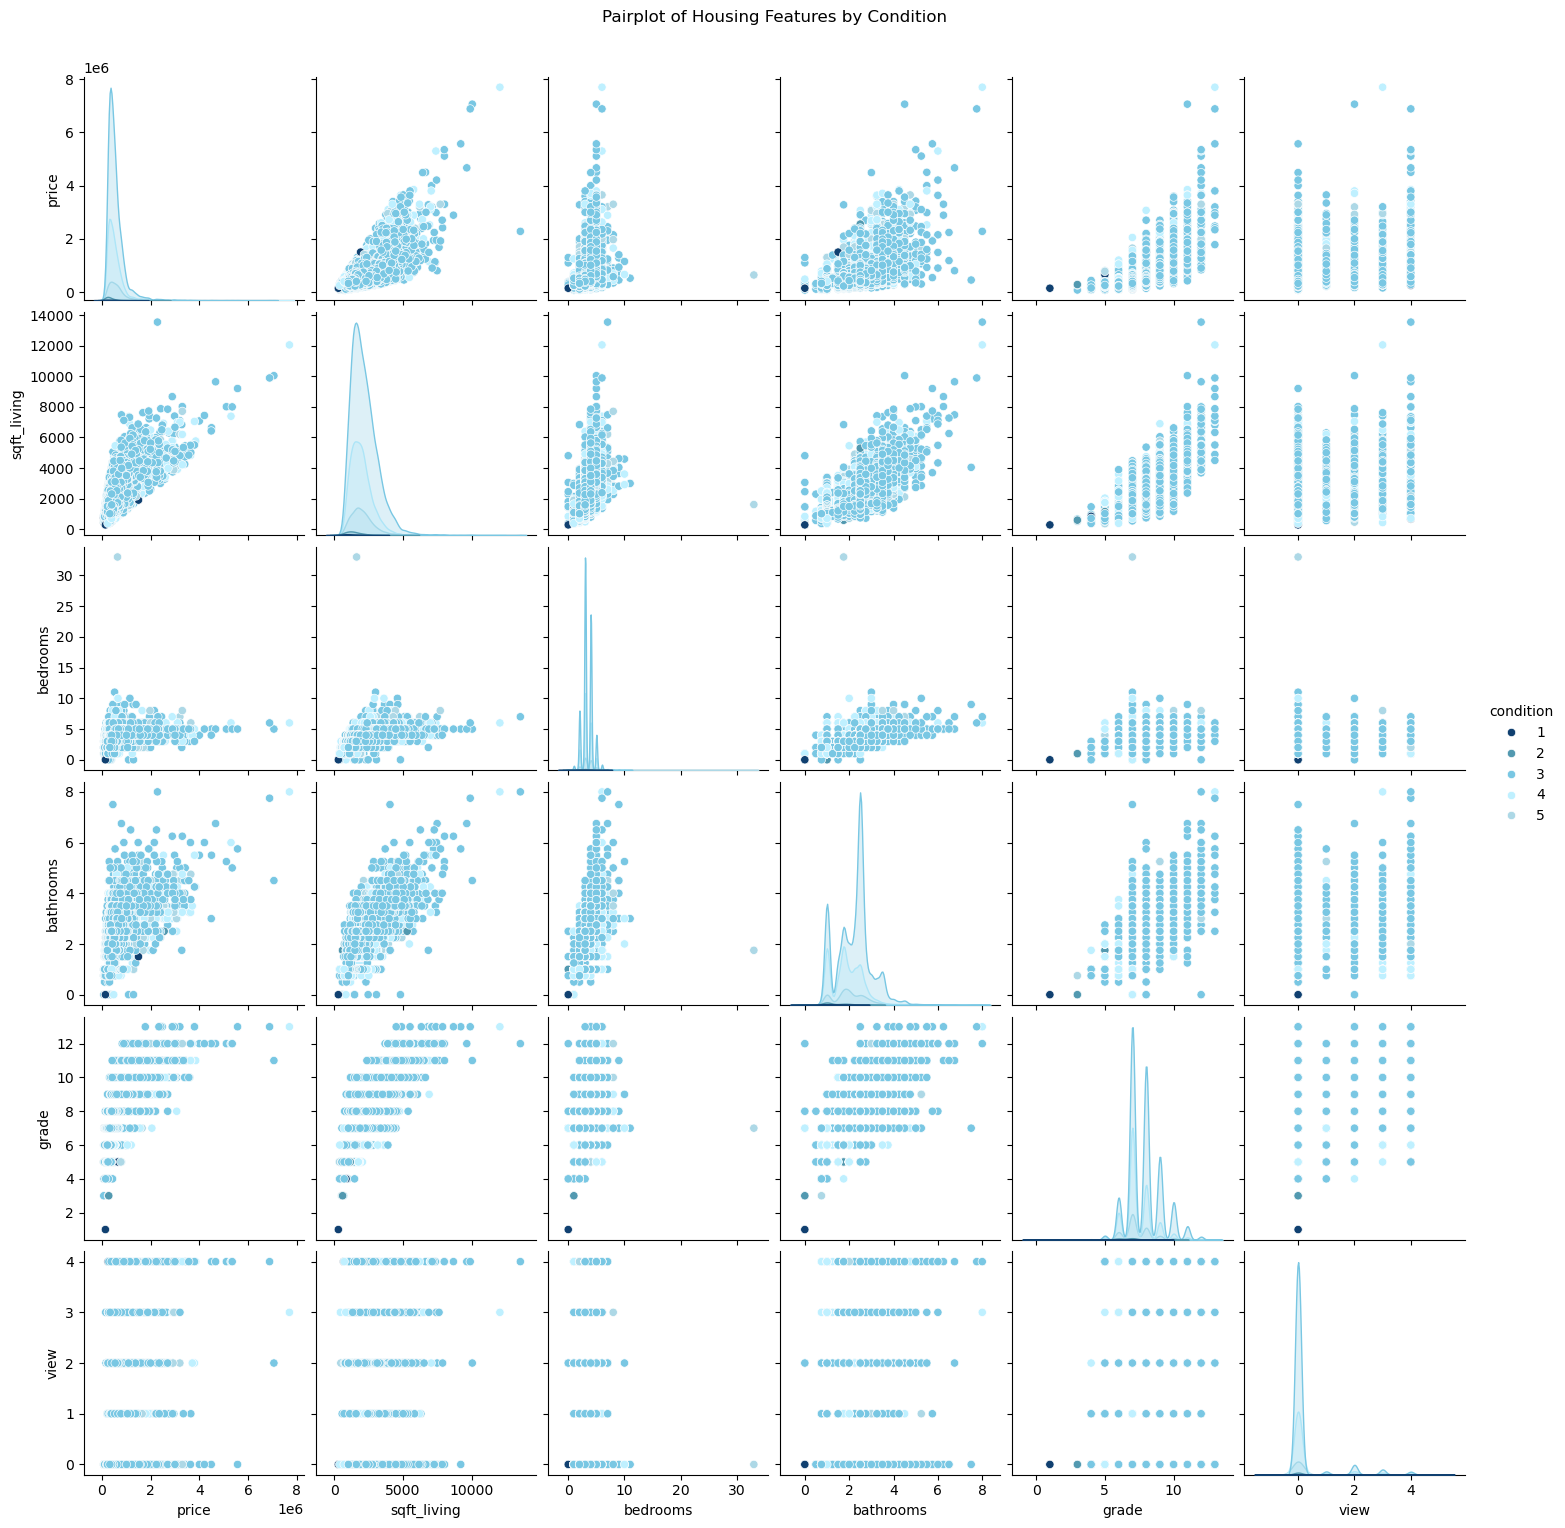

In [13]:
# Creating a pairplot of numerical features based on house condition
pairplot_df = df[['price', 'sqft_living', 'bedrooms', 'bathrooms', 'grade', 'view', 'condition']]

print("Pairplot of the dataset colored by house condition")
plt.figure(figsize=(12,10))
sns.pairplot(pairplot_df, hue='condition', palette=palette)
plt.suptitle('Pairplot of Housing Features by Condition', y=1.02)
plt.show()

### Data Preprocessing

In [15]:
#Checking for null/missing values
total = df.isnull().sum().sort_values(ascending=False)
percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head()

,Total,Percent
id,0,0.0
grade,0,0.0
sqft_living15,0,0.0
long,0,0.0
lat,0,0.0


No null values were identified in the dataset

In [17]:
# Find and display duplicate rows
duplicates = df[df.duplicated()]
duplicates

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15


No Duplicates were found in the Dataset

#### Encoding

In [20]:
#Get list of categorical variables
cat_cols = (df.dtypes == 'object')
object_cols = list(cat_cols[cat_cols].index)
print("Categorical variables in the dataset:", object_cols)

Categorical variables in the dataset: ['date']


In [21]:
cat_vars = ['date']

# Value counts for each categorical variable
for col in cat_vars:
    print(f"Value counts for {col}:")
    print(df[col].value_counts())
    print("\n")

Value counts for date:
date
20140623T000000    142
20140626T000000    131
20140625T000000    131
20140708T000000    127
20150427T000000    126
                  ... 
20141102T000000      1
20150131T000000      1
20150524T000000      1
20140517T000000      1
20140727T000000      1
Name: count, Length: 372, dtype: int64




In [22]:
# Onehot encoding the categorical columns
categorical_columns = ['date']

onehot_encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
df_encoded = pd.DataFrame(onehot_encoder.fit_transform(df[categorical_columns]))
df_encoded.columns = onehot_encoder.get_feature_names_out(categorical_columns)
df = df.drop(categorical_columns, axis=1)

df = pd.concat([df.reset_index(drop=True), df_encoded], axis=1)
df.head()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,date_20150508T000000,date_20150509T000000,date_20150510T000000,date_20150511T000000,date_20150512T000000,date_20150513T000000,date_20150514T000000,date_20150515T000000,date_20150524T000000,date_20150527T000000
0,7229300521,231300.0,2,1.00,1180,5650,1.0,0,0,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,6414100192,538000.0,3,2.25,2570,7242,2.0,0,0,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5631500400,180000.0,2,1.00,770,10000,1.0,0,0,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2487200875,604000.0,4,3.00,1960,5000,1.0,0,0,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1954400510,510000.0,3,2.00,1680,8080,1.0,0,0,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Feature Selection

**Feature Engineering for 'date' column**

One-hot encoding is generally not suitable for high-cardinality categorical variables like 'date', especially when the order and temporal relationships are important. Instead, we can extract relevant features such as the year, month, and day from the 'date' column, to allow the model to learn patterns based on time.

In [25]:
# Reloading the original dataset to get the 'date' column back and remove the 'id' column
df = pd.read_csv(r"C:\Users\gamag\Downloads\Housing.csv")
df = df.drop('id', axis=1)

# Convert 'date' column to datetime objects
df['date'] = pd.to_datetime(df['date'])

# Extracting year, month, and day as new features
df['sale_year'] = df['date'].dt.year
df['sale_month'] = df['date'].dt.month
df['sale_day'] = df['date'].dt.day

# Drop the original 'date' column as it's no longer needed
df = df.drop('date', axis=1)

print("DataFrame after feature engineering 'date' column and dropping 'id' column:")
display(df.head())

DataFrame after feature engineering 'date' column and dropping 'id' column:


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month,sale_day
0,231300.0,2,1.00,1180,5650,1.0,0,0,3,7,...,1955,0,98178,47.5112,-122.257,1340,5650,2014,10,13
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,1951,1991,98125,47.7210,-122.319,1690,7639,2014,12,9
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,1933,0,98028,47.7379,-122.233,2720,8062,2015,2,25
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,1965,0,98136,47.5208,-122.393,1360,5000,2014,12,9
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,1987,0,98074,47.6168,-122.045,1800,7503,2015,2,18


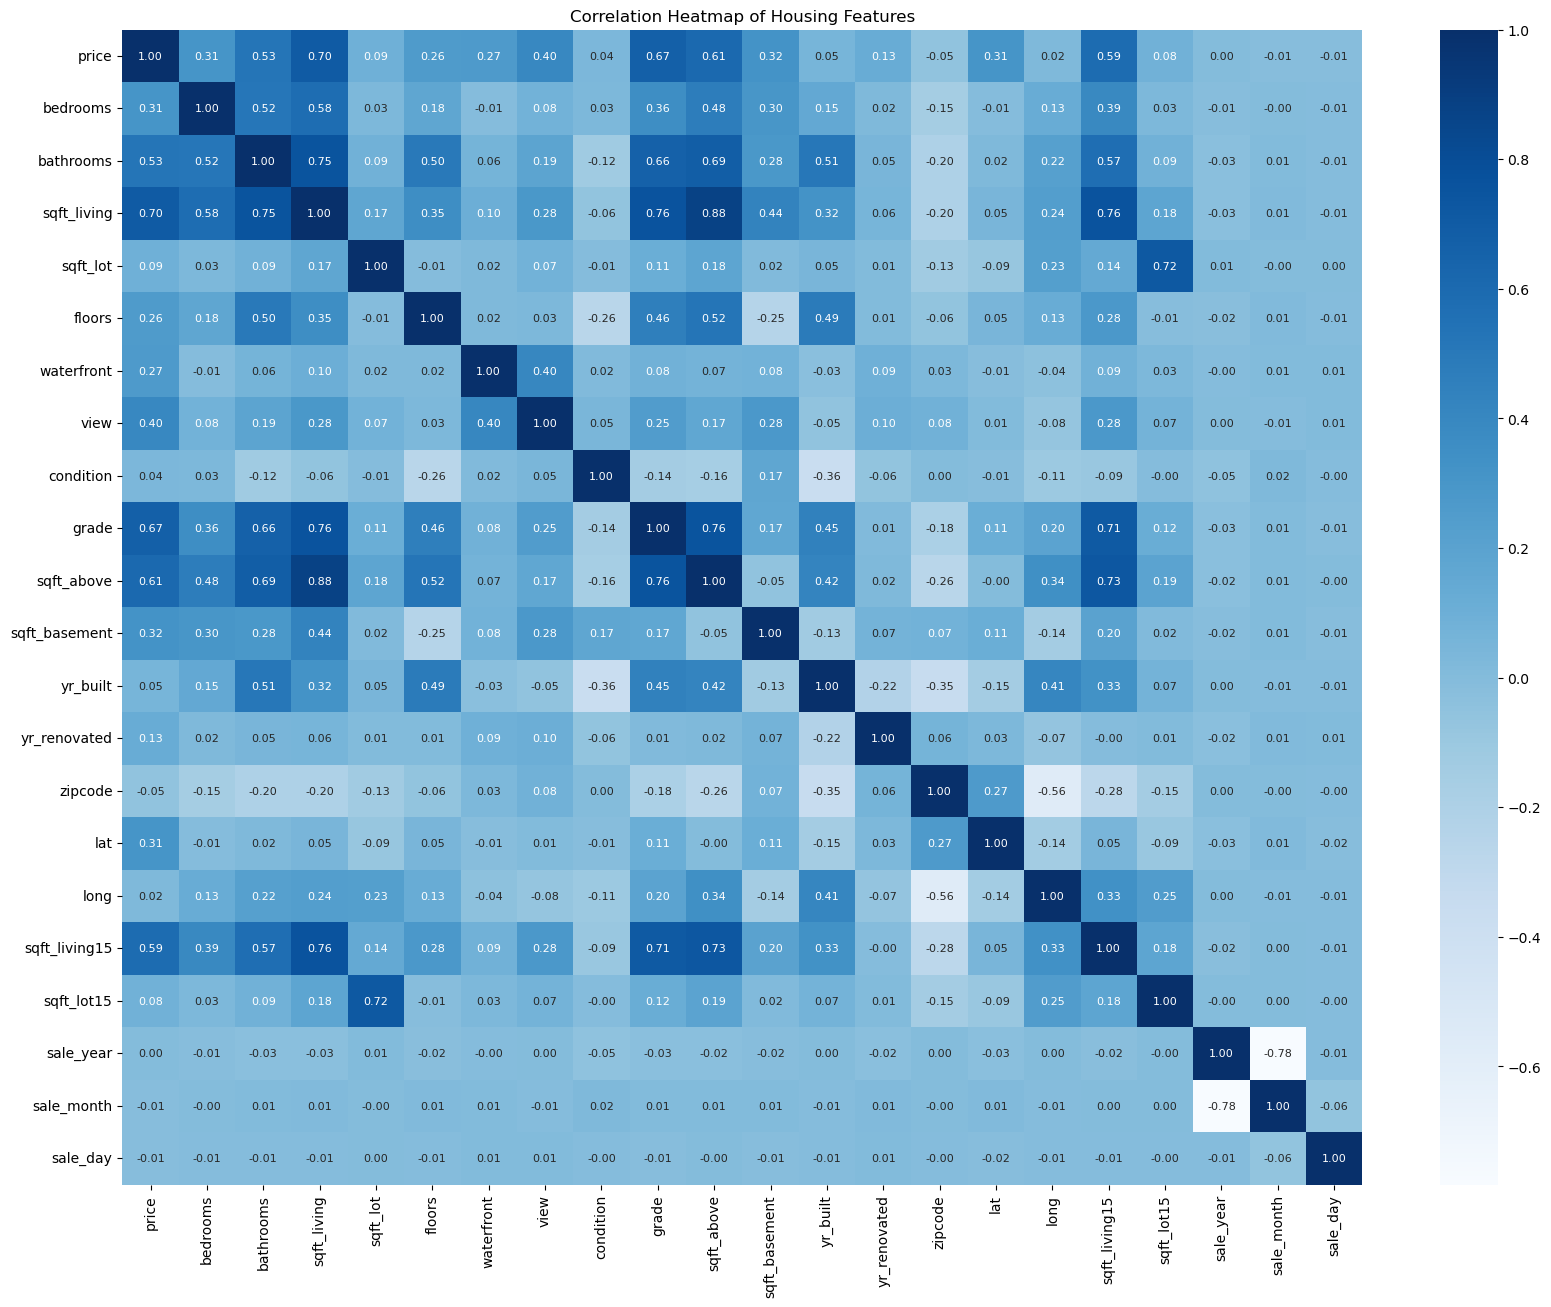

In [26]:
# Correlation heatmap
plt.figure(figsize=(20,15)) 
correlation = df.corr()
sns.heatmap(correlation,cmap='Blues',annot=True, fmt='.2f', annot_kws={"size": 8}) 
plt.title('Correlation Heatmap of Housing Features') 
plt.show()

### Machine Learning Regression 

In [28]:
# Defining features and target variable
target_variable_name = 'price'
features = df.drop(columns=[target_variable_name])
target_variable = df[target_variable_name]

# Splitting the data into train and test sets
X_train, X_test, Y_train, Y_test = train_test_split(features, target_variable, test_size=0.2, random_state=42)

In [29]:
# Scaling (Standardizing) the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
# List of regression models to train and evaluate
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=16),
    'Lasso Regression': Lasso(random_state=16),
    'Decision Tree': DecisionTreeRegressor(random_state=16),
    'Random Forest': RandomForestRegressor(random_state=16),
    'Gradient Boosting': GradientBoostingRegressor(random_state=16),
    'XGBoost': XGBRegressor(random_state=16, eval_metric='rmse'),
    'LightGBM': LGBMRegressor(random_state=16, verbose=-1),
    'AdaBoost': AdaBoostRegressor(random_state=16),
    'K-Nearest Neighbors': KNeighborsRegressor()
}

In [40]:
# Storing the performance of the models
best_model = None
best_params = None
best_r2_score = float('-inf')
best_mae = float('inf')
best_rmse = float('inf')
results = {}

# Loop to train each model and evaluate the performance
for model_name, model in models.items():
    print(f"\n{'='*10} Training {model_name} {'='*10}")

    model.fit(X_train, Y_train)

    Y_pred = model.predict(X_test)
    r2 = r2_score(Y_test, Y_pred)
    mse = mean_squared_error(Y_test, Y_pred)
    mae = mean_absolute_error(Y_test, Y_pred)
    rmse = np.sqrt(mse)

    r2_rounded = round(r2, 2)

    print(f"R² Score: {r2_rounded:.2f}")
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"Mean Absolute Error: {mae:.2f}")
    print(f"Root Mean Squared Error: {rmse:.2f}")

    results[model_name] = {
        "model": model,
        "r2_score": r2_rounded,
        "mse": mse,
        "mae": mae,
        "rmse": rmse,
        "Y_pred": Y_pred
    }


    # Updating the best model: 1. If R² is greater. 2. If R² is the same, choosing the model with the lower MAE
    if (r2_rounded > best_r2_score) or (r2_rounded == best_r2_score and mae < best_mae):
        best_model = model
        best_params = {}
        best_r2_score = r2_rounded
        best_mae = mae
        best_rmse = rmse

# Performance summary of the best model
print(f"\n{'='*10} Best Model {'='*10}")
print(f"Model: {best_model}")
print(f"R² Score: {best_r2_score:.2f}")
print(f"Mean Absolute Error: {best_mae:.2f}")
print(f"Root Mean Squared Error: {best_rmse:.2f}")


========== Training Linear Regression ==========
R² Score: 0.70
Mean Squared Error: 44951464181.51
Mean Absolute Error: 126929.44
Root Mean Squared Error: 212017.60

========== Training Ridge Regression ==========
R² Score: 0.70
Mean Squared Error: 44951738443.11
Mean Absolute Error: 126927.38
Root Mean Squared Error: 212018.25

========== Training Lasso Regression ==========
R² Score: 0.70
Mean Squared Error: 44951502075.93
Mean Absolute Error: 126929.32
Root Mean Squared Error: 212017.69

========== Training Decision Tree ==========
R² Score: 0.71
Mean Squared Error: 44586493068.40
Mean Absolute Error: 105907.76
Root Mean Squared Error: 211155.14

========== Training Random Forest ==========
R² Score: 0.86
Mean Squared Error: 21762258850.24
Mean Absolute Error: 73244.51
Root Mean Squared Error: 147520.37

========== Training Gradient Boosting ==========
R² Score: 0.85
Mean Squared Error: 22515484109.43
Mean Absolute Error: 81097.59
Root Mean Squared Error: 150051.60

========== Trai

#### Hyperparameter Tuning

In [43]:
# Defining the models and the hyperparameter grids for each model
models = {
    'Linear Regression': (LinearRegression(), {

    }),
    'Ridge Regression': (Ridge(random_state=16), {
        'alpha': [0.1, 1, 10, 100],
        'solver': ['auto', 'svd', 'cholesky', 'saga', 'lsqr']
    }),
    'Lasso Regression': (Lasso(random_state=16), {
        'alpha': [0.01, 0.1, 1, 10],
        'max_iter': [1000, 2000, 5000]
    }),
    'Decision Tree': (DecisionTreeRegressor(random_state=16), {
        'criterion': ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }),
    'Random Forest': (RandomForestRegressor(random_state=16), {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'bootstrap': [True, False]
    }),
    'Gradient Boosting': (GradientBoostingRegressor(random_state=16), {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'subsample': [0.5, 0.7, 1.0]
    }),
    'XGBoost': (XGBRegressor(random_state=16, eval_metric='rmse'), {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.5, 0.7, 0.9, 1.0],
        'colsample_bytree': [0.5, 0.7, 0.9, 1.0]
    }),
    'LightGBM': (LGBMRegressor(random_state=16, verbose=-1), {
        'n_estimators': [100, 200, 300],
        'max_depth': [-1, 10, 20, 30],
        'learning_rate': [0.01, 0.1, 0.2],
        'num_leaves': [31, 50, 100]
    }),
    'AdaBoost': (AdaBoostRegressor(random_state=16), {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 1.0],
        'loss': ['linear', 'square', 'exponential']
    }),
    'K-Nearest Neighbors': (KNeighborsRegressor(), {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    })
}

In [59]:
#Speeding up the process
from sklearn.model_selection import RandomizedSearchCV

In [63]:
# Storing the results of the models
best_model = None
best_params = None
best_r2_score = float('-inf')
best_mae = float('inf')
best_rmse = float('inf')
results = {}

# Hyperparameter tuning each model
for model_name, (model, param_grid) in models.items():
    print(f"\n{'='*10} Tuning {model_name} {'='*10}")


    #To speed up the process
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,   
        n_iter=15,                   
        cv=3,                             
        scoring='r2',
        n_jobs=-1,
        random_state=42,
        verbose=0
    )
    
    search.fit(X_train, Y_train)


    # Obtaining the best estimator and parameters
    best_estimator = search.best_estimator_      
    current_best_params = search.best_params_    
    Y_pred = best_estimator.predict(X_test)

    # Evaluation metrics
    r2 = r2_score(Y_test, Y_pred)
    mse = mean_squared_error(Y_test, Y_pred)
    mae = mean_absolute_error(Y_test, Y_pred)
    rmse = np.sqrt(mse)

    r2_rounded = round(r2, 2)

    print(f"R² Score: {r2_rounded:.2f}")
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"Mean Absolute Error: {mae:.2f}")
    print(f"Root Mean Squared Error: {rmse:.2f}")
    print(f"Best Parameters: {current_best_params}")

    results[model_name] = {
        "model": best_estimator,
        "r2_score": r2_rounded,
        "mse": mse,
        "mae": mae,
        "rmse": rmse,
        "best_params": current_best_params,
        "Y_pred": Y_pred
    }

    # Updating the best model: 1. If R² is greater. 2. If R² is the same, choose the model with the lower MAE.
    if (r2_rounded > best_r2_score) or (r2_rounded == best_r2_score and mae < best_mae):
        best_model = best_estimator
        best_params = current_best_params
        best_r2_score = r2_rounded
        best_mae = mae
        best_rmse = rmse

# Performance summary of the best model
print(f"\n{'='*10} Best Model {'='*10}")
print(f"Model: {best_model}")
print(f"Parameters: {best_params}")
print(f"R² Score: {best_r2_score:.2f}")
print(f"Mean Absolute Error: {best_mae:.2f}")
print(f"Root Mean Squared Error: {best_rmse:.2f}")


========== Tuning Linear Regression ==========
R² Score: 0.70
Mean Squared Error: 44951464181.51
Mean Absolute Error: 126929.44
Root Mean Squared Error: 212017.60
Best Parameters: {}

========== Tuning Ridge Regression ==========
R² Score: 0.70
Mean Squared Error: 44980783013.69
Mean Absolute Error: 126730.81
Root Mean Squared Error: 212086.73
Best Parameters: {'solver': 'saga', 'alpha': 100}

========== Tuning Lasso Regression ==========
R² Score: 0.70
Mean Squared Error: 44952463097.10
Mean Absolute Error: 126925.08
Root Mean Squared Error: 212019.96
Best Parameters: {'max_iter': 5000, 'alpha': 10}

========== Tuning Decision Tree ==========
R² Score: 0.78
Mean Squared Error: 33097222067.59
Mean Absolute Error: 94829.88
Root Mean Squared Error: 181926.42
Best Parameters: {'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 10, 'criterion': 'friedman_mse'}

========== Tuning Random Forest ==========
R² Score: 0.86
Mean Squared Error: 21460034495.71
Mean Absolute Error: 73117.

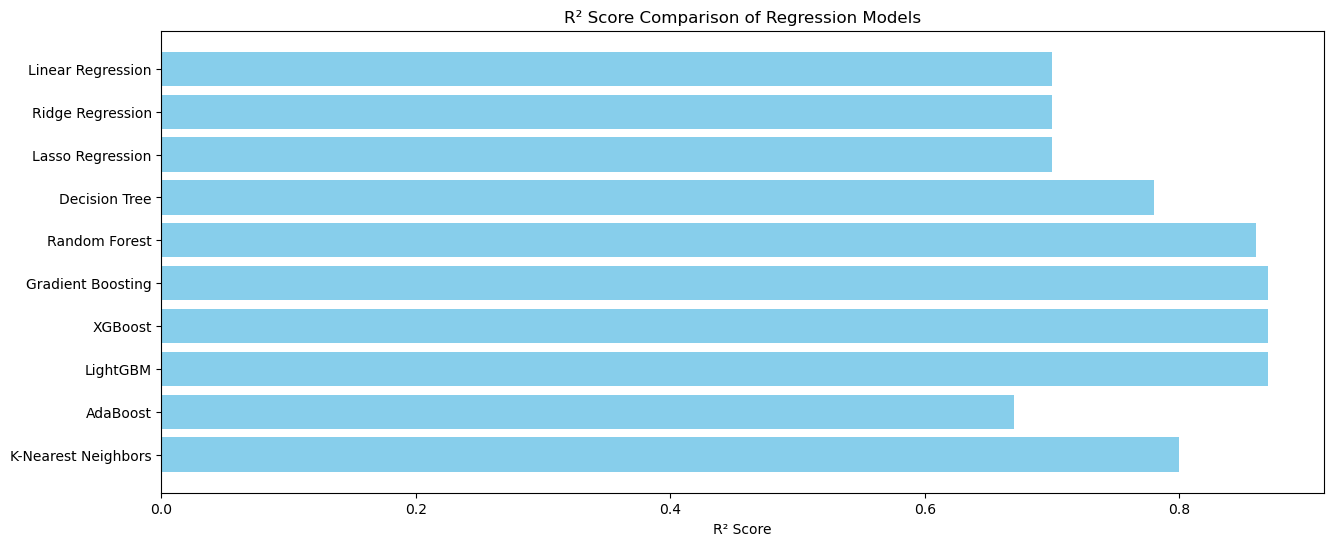

In [85]:
# Bar chart displaying R² values of each model
plt.figure(figsize=(15, 6))
plt.barh(list(results.keys()), [res["r2_score"] for res in results.values()], color='skyblue')
plt.xlabel("R² Score")
plt.title("R² Score Comparison of Regression Models")
plt.gca().invert_yaxis()
plt.show()

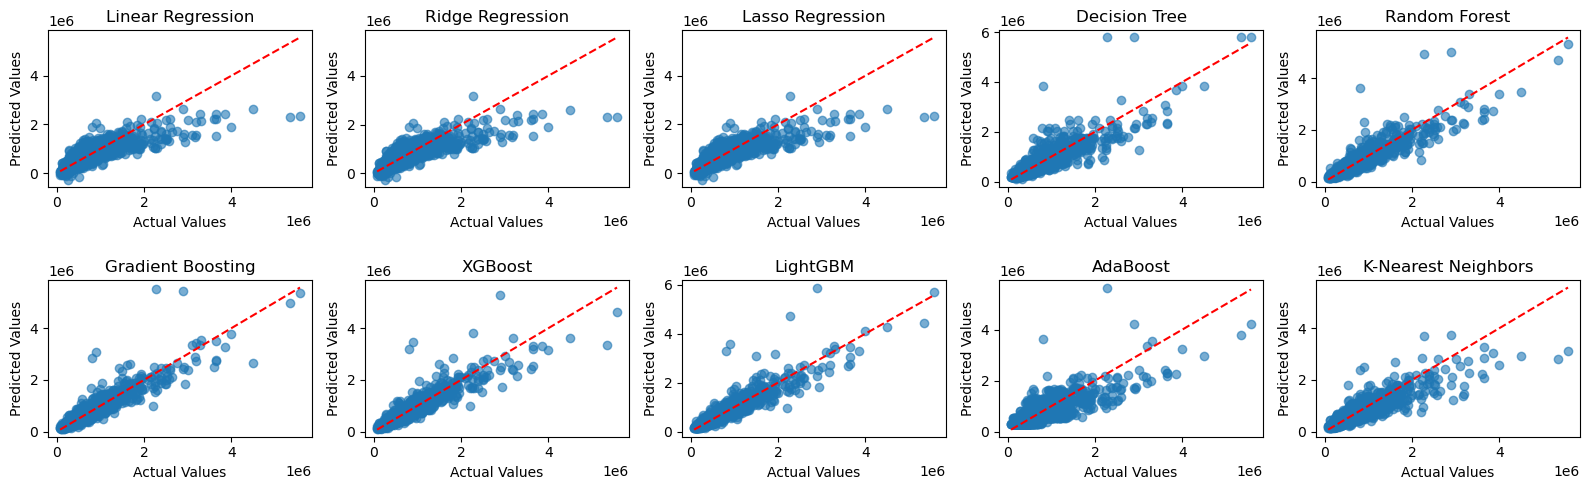

In [93]:
# Subplots for Actual vs Predicted values of each model
fig, axes = plt.subplots(2, 5, figsize=(16, 5))
axes = axes.flatten()

for idx, (model_name, res) in enumerate(results.items()):
    axes[idx].scatter(Y_test, res["Y_pred"], alpha=0.6)
    axes[idx].plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], color='red', linestyle='--')
    axes[idx].set_title(model_name)
    axes[idx].set_xlabel('Actual Values')
    axes[idx].set_ylabel('Predicted Values')

plt.tight_layout()
plt.show()

'le6' > Scientefic notation (for 1,000,000's)


Regression Metrics:
Mean Absolute Error (MAE): 67174.61
Mean Squared Error (MSE): 19328268821.07
Root Mean Squared Error (RMSE): 139026.14
R² Score: 0.87


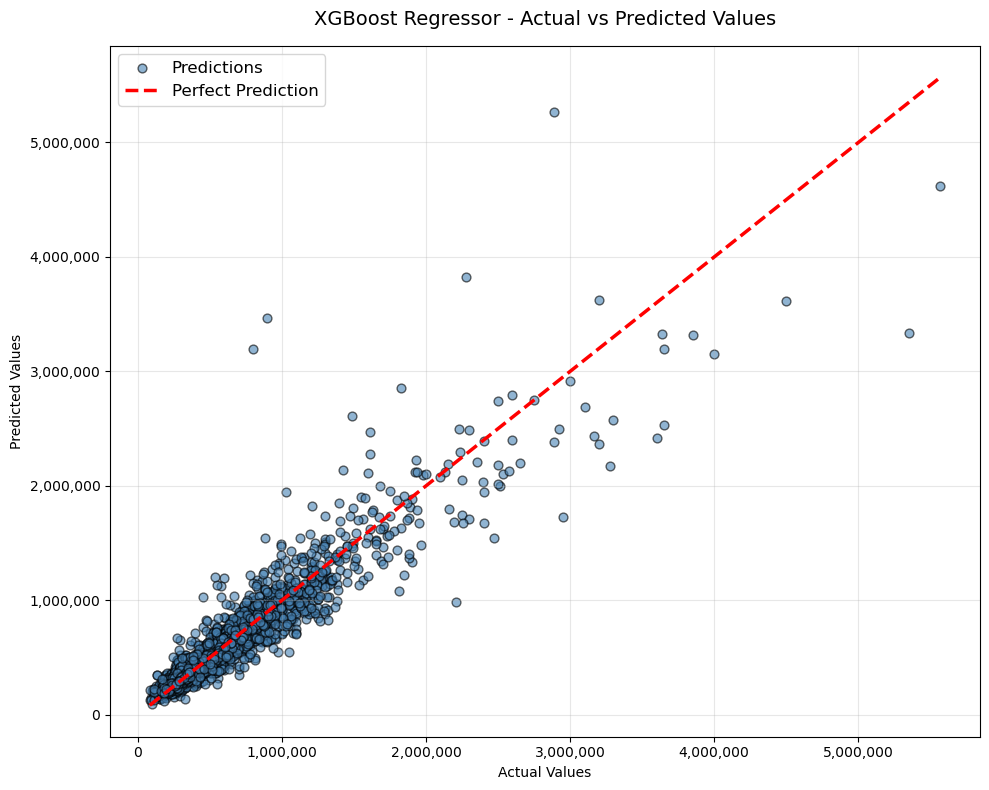

In [108]:
# Regression metrics for the best model
Y_pred = best_model.predict(X_test)
print("\nRegression Metrics:")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(Y_test, Y_pred):.2f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(Y_test, Y_pred):.2f}")
print(f"Root Mean Squared Error (RMSE): {mean_squared_error(Y_test, Y_pred) ** 0.5:.2f}")
print(f"R² Score: {r2_score(Y_test, Y_pred):.2f}")

# Plotting the actual vs predicted values
import matplotlib.ticker as ticker

plt.figure(figsize=(10, 8))

# Scatter + perfect prediction line
plt.scatter(Y_test, Y_pred, alpha=0.6, s=40, color='steelblue', edgecolor='black', label='Predictions')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 
         color='red', linestyle='--', linewidth=2.5, label='Perfect Prediction')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('XGBoost Regressor - Actual vs Predicted Values', fontsize=14, pad=15)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)


ax = plt.gca()
ax.ticklabel_format(style='plain', axis='both')                    
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}')) 
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

## **Classification**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Dataset link**

https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset

In [7]:
# Uploding the Dataset
df = pd.read_csv(r"C:\Users\gamag\Downloads\diabetes_prediction_dataset.csv")

In [3]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


### **Exploratory Data Analysis**

In [4]:
# Checking the dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [5]:
df.shape

(100000, 9)

In [6]:
#Checking the data types
df.dtypes

,0
gender,object
age,float64
hypertension,int64
heart_disease,int64
smoking_history,object
bmi,float64
HbA1c_level,float64
blood_glucose_level,int64
diabetes,int64


In [7]:
#Checking for missing values
missing_per_column = df.isnull().sum()
print("Missing values per column:")
print(missing_per_column)

Missing values per column:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [8]:
#Checking for duplicates
duplicates = df.duplicated().sum()
print(f"\nNumber of Duplicate Rows: {duplicates}")


Number of Duplicate Rows: 3854


In [9]:
#Overview of the descriptive statistics of the dataframe
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


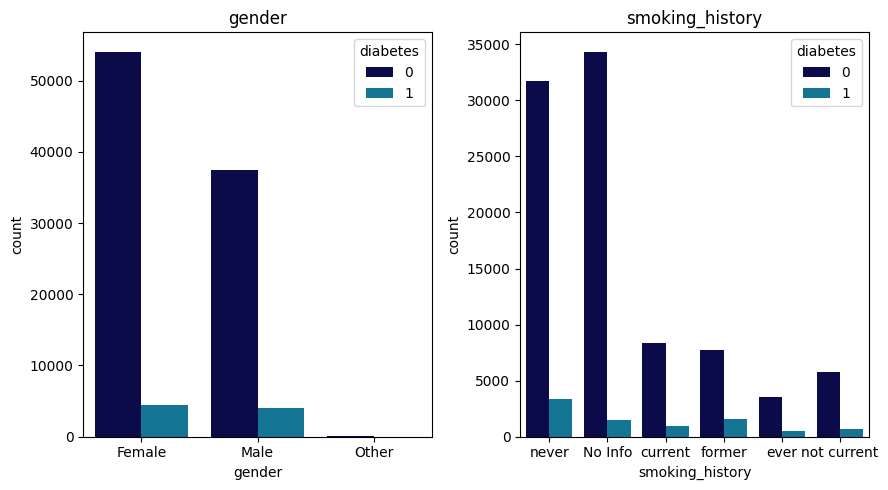

In [10]:
# Visualising the distribution of the categorical columns

cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
n_cols = 5
n_rows = (len(cat_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(22, 5 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    sns.countplot(x=col, data=df, hue='diabetes', ax=ax, palette='ocean')
    ax.set_title(f'{col}')

for i in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [11]:
# Obtaining the list of numerical columns
num_cols = df.select_dtypes(include=['number']).columns.tolist()
num_cols

['age',
 'hypertension',
 'heart_disease',
 'bmi',
 'HbA1c_level',
 'blood_glucose_level',
 'diabetes']

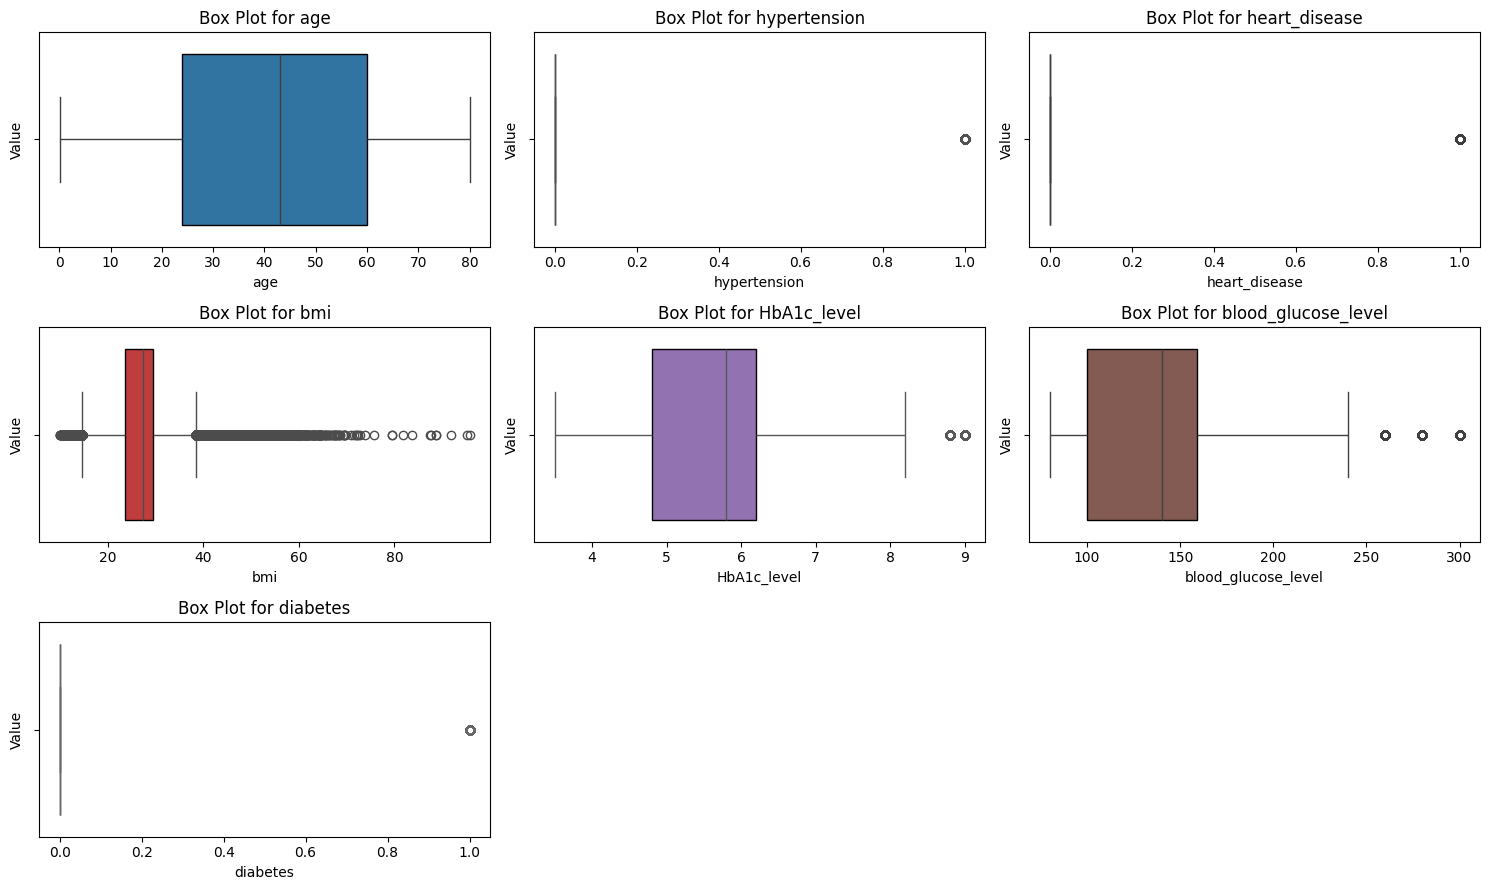

In [12]:
#Visualizing the distribution of numerical features
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = len(numerical_columns)

rows = (num_cols + 2) // 3
cols = 3
fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows), dpi=100)
axes = axes.flatten()

palette = sns.color_palette('tab10', n_colors=num_cols)

for i, col in enumerate(numerical_columns):
    sns.boxplot(data=df, x=col, ax=axes[i], color=palette[i], boxprops=dict(edgecolor='black'))
    axes[i].set_title(f'Box Plot for {col}', fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Value', fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

Pairplot of the dataset


<Figure size 640x480 with 0 Axes>

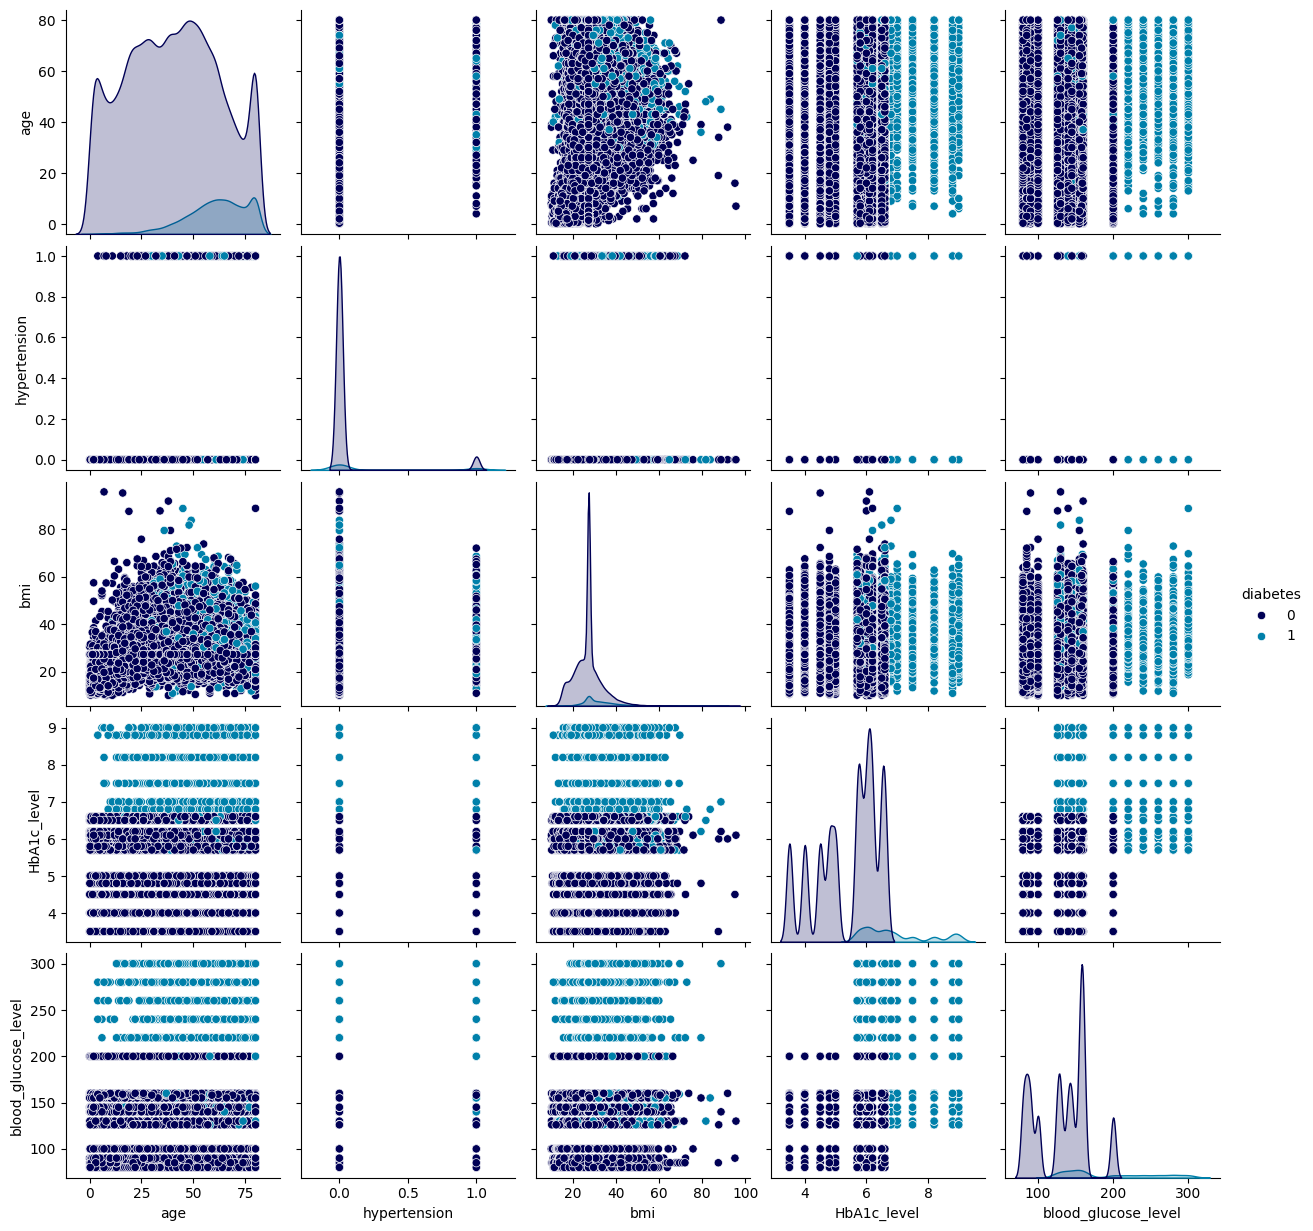

In [13]:
# Pairplot to visualise the relationship between features based on Diabetes status
df_subset = df.drop(columns=['heart_disease'])
print("Pairplot of the dataset")
plt.figure()
sns.pairplot(df_subset, hue='diabetes', palette= 'ocean')
plt.show()

In [14]:
# Checking for value counts of the target variable
df['diabetes'].value_counts()

,count
diabetes,
0,91500
1,8500


### Data Pre-Processing

In [15]:
#Checking for Duplicates
duplicates = df[df.duplicated()]
duplicates

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
2756,Male,80.0,0,0,No Info,27.32,6.6,159,0
3272,Female,80.0,0,0,No Info,27.32,3.5,80,0
3418,Female,19.0,0,0,No Info,27.32,6.5,100,0
3939,Female,78.0,1,0,former,27.32,3.5,130,0
3960,Male,47.0,0,0,No Info,27.32,6.0,200,0
...,...,...,...,...,...,...,...,...,...
99980,Female,52.0,0,0,never,27.32,6.1,145,0
99985,Male,25.0,0,0,No Info,27.32,5.8,145,0
99989,Female,26.0,0,0,No Info,27.32,5.0,158,0
99990,Male,39.0,0,0,No Info,27.32,6.1,100,0


In [16]:
#Removing Duplicates
df = df.drop_duplicates()
print("DataFrame after removing duplicates:")
display(df.head())

DataFrame after removing duplicates:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [17]:
# Creating a DataFrame to depict minimum and maximum values
min_max_table = pd.DataFrame({
    'Column': numerical_columns,
    'Minimum Value': [df[col].min() for col in numerical_columns],
    'Maximum Value': [df[col].max() for col in numerical_columns]
})

from tabulate import tabulate    # Display the table
print(tabulate(min_max_table, headers='keys', tablefmt='fancy_grid', showindex=False))

╒═════════════════════╤═════════════════╤═════════════════╕
│ Column              │   Minimum Value │   Maximum Value │
╞═════════════════════╪═════════════════╪═════════════════╡
│ age                 │            0.08 │           80    │
├─────────────────────┼─────────────────┼─────────────────┤
│ hypertension        │            0    │            1    │
├─────────────────────┼─────────────────┼─────────────────┤
│ heart_disease       │            0    │            1    │
├─────────────────────┼─────────────────┼─────────────────┤
│ bmi                 │           10.01 │           95.69 │
├─────────────────────┼─────────────────┼─────────────────┤
│ HbA1c_level         │            3.5  │            9    │
├─────────────────────┼─────────────────┼─────────────────┤
│ blood_glucose_level │           80    │          300    │
├─────────────────────┼─────────────────┼─────────────────┤
│ diabetes            │            0    │            1    │
╘═════════════════════╧═════════════════

In [18]:
df.shape

(96146, 9)

##### Unrealistic values have been rectified

### Encoding and feature selection

In [19]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_selection import SelectKBest
from sklearn.metrics import (
    classification_report, accuracy_score, precision_score, roc_auc_score,
    auc, recall_score, f1_score, roc_curve, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

In [20]:
# Obtaining the list of categorical variables
cat_cols = (df.dtypes == 'object')
object_cols = list(cat_cols[cat_cols].index)
print("Categorical variables in the dataset:", object_cols)

Categorical variables in the dataset: ['gender', 'smoking_history']


In [21]:
cat_vars = ['gender', 'smoking_history']

# Value counts for each categorical variable
for col in cat_vars:
    print(f"Value counts for {col}:")
    print(df[col].value_counts())
    print("\n")

Value counts for gender:
gender
Female    56161
Male      39967
Other        18
Name: count, dtype: int64


Value counts for smoking_history:
smoking_history
never          34398
No Info        32887
former          9299
current         9197
not current     6367
ever            3998
Name: count, dtype: int64




In [22]:
# One-hot encoding the categorical columns (nominal)
from sklearn.preprocessing import OneHotEncoder

categorical_columns = ['gender', 'smoking_history']

# Checking if categorical columns still exist in the DataFrame before encoding
columns_to_encode = [col for col in categorical_columns if col in df.columns]

if columns_to_encode:
    onehot_encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
    df_encoded = pd.DataFrame(onehot_encoder.fit_transform(df[columns_to_encode]))
    df_encoded.columns = onehot_encoder.get_feature_names_out(columns_to_encode)
    df = df.drop(columns_to_encode, axis=1)
    df = pd.concat([df.reset_index(drop=True), df_encoded], axis=1)
display(df.head())

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,54.0,0,0,27.32,6.6,80,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,28.0,0,0,27.32,5.7,158,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,36.0,0,0,23.45,5.0,155,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,76.0,1,1,20.14,4.8,155,0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


In [23]:
# Mapping categorical variables to numerical values based on rank

#Smoking history
smoking_history_mapping = {'never': 0, 'former': 1, 'current': 2, 'not current': 3, 'ever': 4}

<Axes: >

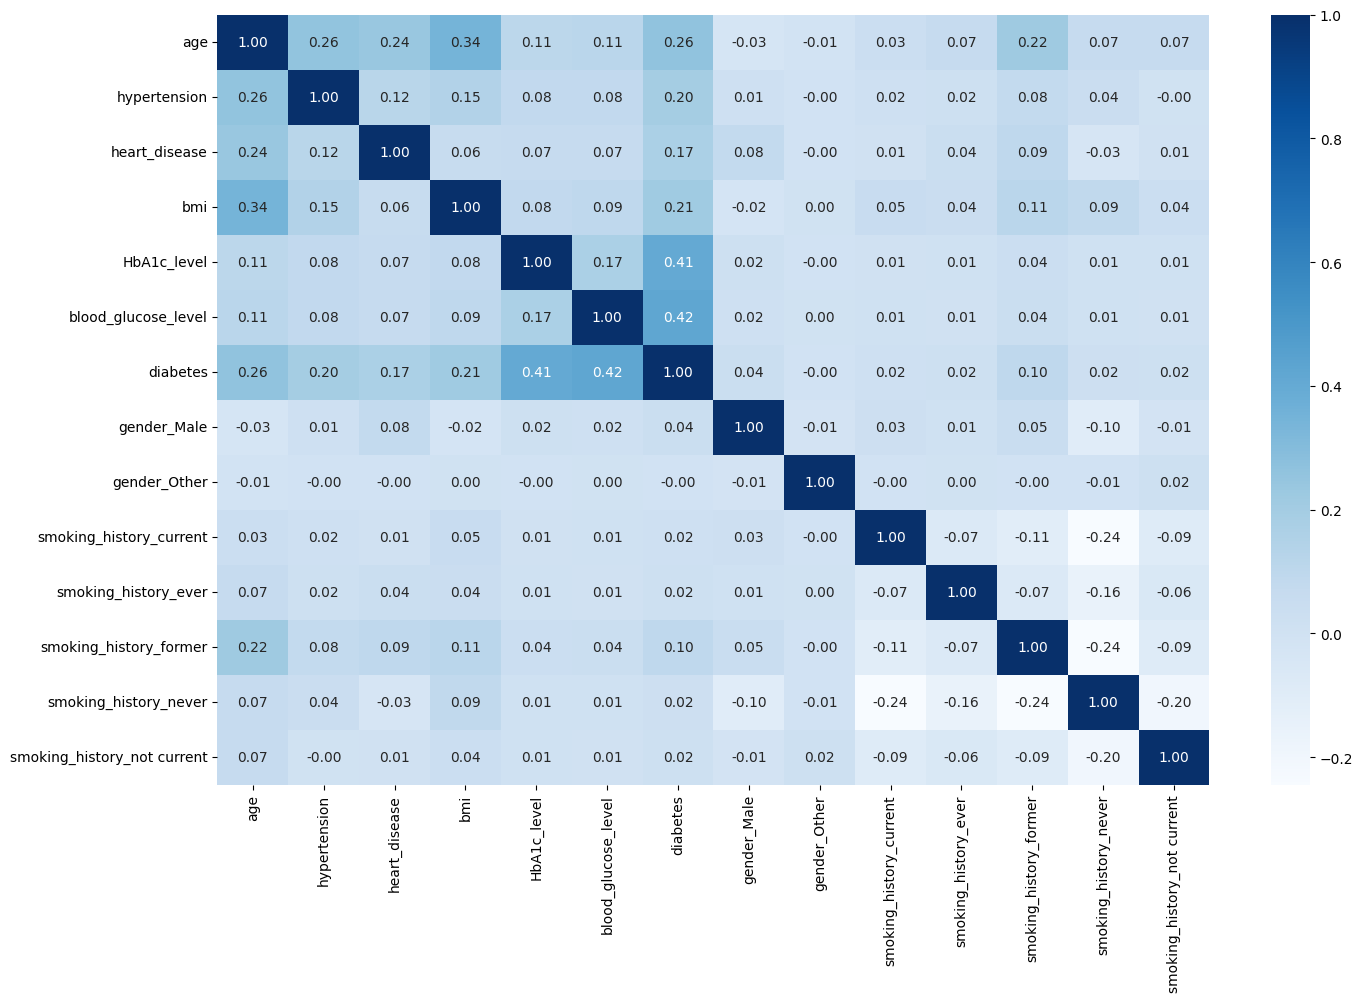

In [24]:
# Correlation heatmap
plt.figure(len(df),figsize=(16,10))
correlation = df.corr(numeric_only=True)
sns.heatmap(correlation,cmap='Blues',annot=True, fmt='.2f')

#### Machine learning Classification

In [25]:
# Defining features and target variable
features = df.drop(columns=['diabetes'])
target_variable = df['diabetes']

# Splitting the data into train and test sets
X_train, X_test, Y_train, Y_test = train_test_split(features, target_variable, test_size=0.2, random_state=42)

In [26]:
# Scaling the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.0 MB/s eta 0:00:00


In [29]:
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import AdaBoostClassifier

# List of classification models to be trained and evaluated
models = {
    'Logistic Regression': LogisticRegression(random_state=16),
    'Decision Tree': DecisionTreeClassifier(random_state=16),
    'Random Forest': RandomForestClassifier(random_state=16),
    'XGBoost': XGBClassifier(random_state=16, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=16, verbose=-1),
    'CatBoost': CatBoostClassifier(random_state=16, verbose=0),
    'AdaBoost': AdaBoostClassifier(random_state=16),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

In [30]:
# Storing the best models
best_model = None
best_params = None
best_accuracy = 0
model_performance = {}

# Training each model and obtaining evaluation metrics
for model_name, model in models.items():
    print(f"\n{'='*10} Training {model_name} {'='*10}")

    model.fit(X_train, Y_train)

    Y_pred = model.predict(X_test)
    Y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    # Accuracy
    accuracy = accuracy_score(Y_test, Y_pred)
    print(f"Accuracy: {accuracy:.2f}")

    # Classification report
    report = classification_report(Y_test, Y_pred)
    print("Classification Report:\n", report)

    # Confusion matrix
    cm = confusion_matrix(Y_test, Y_pred)
    print("Confusion Matrix:\n", cm)

    # ROC-AUC score
    roc_auc = roc_auc_score(Y_test, Y_pred_proba) if Y_pred_proba is not None else None
    print(f"ROC-AUC Score: {roc_auc:.2f}" if roc_auc else "ROC-AUC Score: Not Available")

    # Store model performance to compare
    model_performance[model_name] = {
        "model": model,
        "accuracy": accuracy,
        "roc_auc": roc_auc
    }

    # Updating the best model when the accuracy is higher
    if accuracy > best_accuracy:
        best_model = model
        best_params = {}
        best_accuracy = accuracy


 # Display the resuls of the best model
print(f"\n{'='*10} Best Model {'='*10}")
print(f"Model: {best_model}")
print(f"Accuracy: {best_accuracy:.2f}")


========== Training Logistic Regression ==========
Accuracy: 0.96
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.98     17509
           1       0.85      0.63      0.72      1721

    accuracy                           0.96     19230
   macro avg       0.91      0.81      0.85     19230
weighted avg       0.95      0.96      0.95     19230

Confusion Matrix:
 [[17325   184]
 [  641  1080]]
ROC-AUC Score: 0.96

========== Training Decision Tree ==========
Accuracy: 0.95
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97     17509
           1       0.71      0.74      0.73      1721

    accuracy                           0.95     19230
   macro avg       0.84      0.86      0.85     19230
weighted avg       0.95      0.95      0.95     19230

Confusion Matrix:
 [[16982   527]
 [  442  1279]]
ROC-AUC Score: 0.86

========== Training Random Fo

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:08:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.97
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98     17509
           1       0.96      0.69      0.80      1721

    accuracy                           0.97     19230
   macro avg       0.96      0.85      0.89     19230
weighted avg       0.97      0.97      0.97     19230

Confusion Matrix:
 [[17454    55]
 [  526  1195]]
ROC-AUC Score: 0.98

========== Training LightGBM ==========


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.97
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98     17509
           1       0.98      0.69      0.81      1721

    accuracy                           0.97     19230
   macro avg       0.98      0.84      0.90     19230
weighted avg       0.97      0.97      0.97     19230

Confusion Matrix:
 [[17489    20]
 [  540  1181]]
ROC-AUC Score: 0.98

========== Training CatBoost ==========
Accuracy: 0.97
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98     17509
           1       0.96      0.70      0.81      1721

    accuracy                           0.97     19230
   macro avg       0.96      0.85      0.90     19230
weighted avg       0.97      0.97      0.97     19230

Confusion Matrix:
 [[17455    54]
 [  521  1200]]
ROC-AUC Score: 0.98

========== Training AdaBoost ==========
Accuracy: 0.97
Classification Report:
        

### **Hyperparameter Tuning**

In [35]:
models = {
    'Logistic Regression': (LogisticRegression(random_state=16), {
        'class_weight': [None, 'balanced'],
        'solver': ['lbfgs', 'sag'],
        'C': [5, 10, 20],
        'max_iter': [400, 500, 600]
    }),
    'Decision Tree': (DecisionTreeClassifier(random_state=16), {
        'criterion': ['entropy'],
        'max_depth': [8, 10, 12],
        'min_samples_split': [8, 10, 12],
        'min_samples_leaf': [1, 2, 3]
    }),
    'Random Forest': (RandomForestClassifier(random_state=16), {
        'n_estimators': [250, 300, 350],
        'max_depth': [18, 20, 22],
        'min_samples_split': [4, 5, 6],
        'min_samples_leaf': [3, 4, 5],
        'bootstrap': [True]
    }),
    'XGBoost': (XGBClassifier(random_state=16, use_label_encoder=False, eval_metric='logloss'), {
        'n_estimators': [180, 200, 220],
        'max_depth': [6, 7, 8],
        'learning_rate': [0.008, 0.01, 0.012],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0]
    }),
    'LightGBM': (LGBMClassifier(random_state=16, verbose=-1), {
        'n_estimators': [80, 100, 120],
        'max_depth': [8, 10, 12],
        'learning_rate': [0.008, 0.01, 0.012],
        'num_leaves': [25, 31, 35]
    }),
    'CatBoost': (CatBoostClassifier(random_state=16, verbose=0), {
        'iterations': [250, 300, 350],
        'depth': [2, 3, 4],
        'learning_rate': [0.008, 0.01, 0.012]
    }),
    'AdaBoost': (AdaBoostClassifier(random_state=16), {
        'n_estimators': [40, 50, 60],
        'learning_rate': [0.8, 1.0, 1.2]
    }),
    'K-Nearest Neighbors': (KNeighborsClassifier(), {
        'n_neighbors': [7, 9, 11],
        'weights': ['uniform'],
        'metric': ['euclidean']
    })
}

In [39]:
from sklearn.model_selection import RandomizedSearchCV
import warnings
warnings.filterwarnings('ignore')

# Initializing variables to track the best model
best_model = None
best_params = None
best_accuracy = 0
model_performance = {}

# Hyperparameter tuning each model and obtaining performance metrics
for model_name, (model, param_grid) in models.items():
    print(f"\n{'='*10} Tuning {model_name} {'='*10}")

    # Randomized Search with 3-Fold Cross-Validation
    random_search = RandomizedSearchCV(estimator=model, param_distributions=param_grid,
                                       n_iter=10, cv=3, scoring='accuracy', n_jobs=-1, random_state=16)
    random_search.fit(X_train, Y_train)

    # Obtaining the best model and parameters
    best_estimator = random_search.best_estimator_
    best_hyperparams = random_search.best_params_
    Y_pred = best_estimator.predict(X_test)
    Y_pred_proba = best_estimator.predict_proba(X_test)[:, 1] if hasattr(best_estimator, "predict_proba") else None

    # Accuracy
    accuracy = accuracy_score(Y_test, Y_pred)
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Best Parameters: {best_hyperparams}")

    # Classification report
    report = classification_report(Y_test, Y_pred)
    print("Classification Report:\n", report)

    # Confusion matrix
    cm = confusion_matrix(Y_test, Y_pred)
    print("Confusion Matrix:\n", cm)

    # ROC-AUC score
    roc_auc = roc_auc_score(Y_test, Y_pred_proba) if Y_pred_proba is not None else None
    print(f"ROC-AUC Score: {roc_auc:.2f}" if roc_auc else "ROC-AUC Score: Not Available")

    # Store model performance for comparison
    model_performance[model_name] = {
        "best_model": best_estimator,
        "best_params": best_hyperparams,
        "accuracy": accuracy,
        "roc_auc": roc_auc
    }

    # Updating the best model when the accuracy is higher
    if accuracy > best_accuracy:
        best_model = best_estimator
        best_params = best_hyperparams
        best_accuracy = accuracy

# Display best model details
print(f"\n{'='*10} Best Model {'='*10}")
print(f"Model: {best_model}")
print(f"Parameters: {best_params}")
print(f"Accuracy: {best_accuracy:.2f}")


========== Tuning Logistic Regression ==========
Accuracy: 0.96
Best Parameters: {'solver': 'sag', 'max_iter': 500, 'class_weight': None, 'C': 10}
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.98     17509
           1       0.85      0.63      0.72      1721

    accuracy                           0.96     19230
   macro avg       0.91      0.81      0.85     19230
weighted avg       0.95      0.96      0.95     19230

Confusion Matrix:
 [[17325   184]
 [  641  1080]]
ROC-AUC Score: 0.96

========== Tuning Decision Tree ==========
Accuracy: 0.97
Best Parameters: {'min_samples_split': 8, 'min_samples_leaf': 3, 'max_depth': 8, 'criterion': 'entropy'}
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98     17509
           1       1.00      0.67      0.80      1721

    accuracy                           0.97     19230
   macro avg       0.98  


Classification Report: RandomForest Classifier
               precision    recall  f1-score   support

 No Diabetes       0.97      1.00      0.98     17509
    Diabetes       0.99      0.68      0.81      1721

    accuracy                           0.97     19230
   macro avg       0.98      0.84      0.89     19230
weighted avg       0.97      0.97      0.97     19230



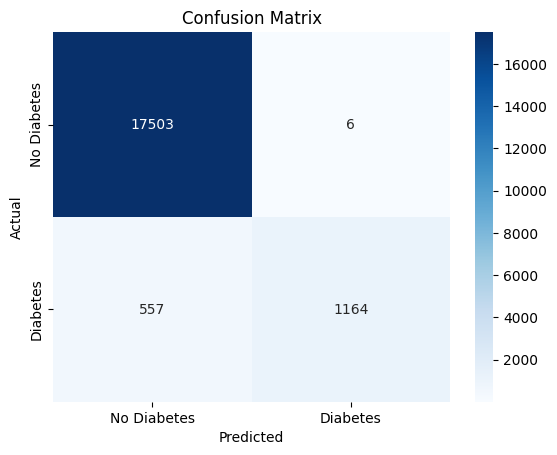

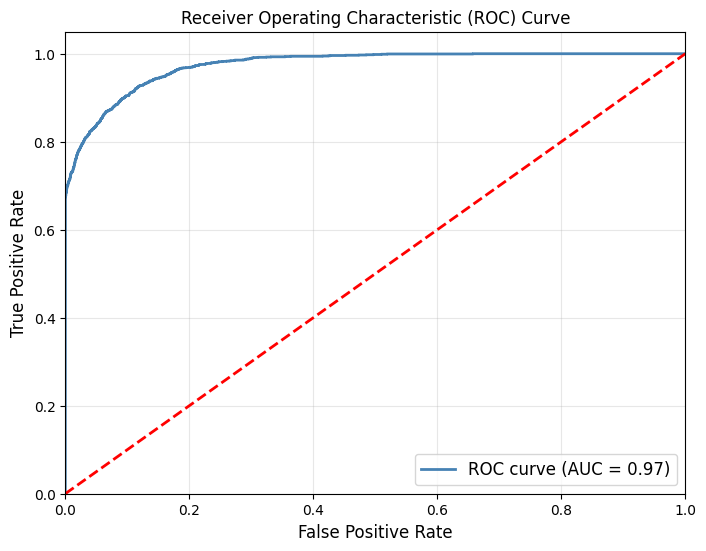

In [40]:
# Classification report and confusion matrix of the best model
Y_pred = best_model.predict(X_test)
print("\nClassification Report: RandomForest Classifier\n", classification_report(Y_test, Y_pred, target_names=['No Diabetes', 'Diabetes']))
conf_matrix = confusion_matrix(Y_test, Y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Predicting the probabilities
y_probs = best_model.predict_proba(X_test)[:, 1]

# Plotting the ROC curve and displaying the AUC
fpr, tpr, thresholds = roc_curve(Y_test, y_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(alpha=0.3)
plt.show()